---
## Étape 0 · Imports & Configuration

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Preprocessing & Feature Selection ────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer   # must come BEFORE import
from sklearn.impute import IterativeImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold

# ── Class imbalance ───────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Persistence ───────────────────────────────────────────────────────────────
import joblib
import os

# ── Display ───────────────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Color constants used across plots
BLUE = "#4C9BE8"
ORANGE = "#E8A44C"
RED = "#E85C4C"
CHURN_PALETTE = {0: BLUE, 1: RED}

print('✅  Imports OK')

✅  Imports OK


## Étape 1 · Data visual


In [2]:
# ── 1.1  Chargement ───────────────────────────────────────────────────────────
RAW_PATH = r'..\data\raw\retail_customers_COMPLETE_CATEGORICAL.csv'
df_raw = pd.read_csv(RAW_PATH)
df     = df_raw.copy()
print(f'Raw shape : {df.shape}')

Raw shape : (4372, 52)


In [3]:
df.head() 
df.info()
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

<class 'pandas.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 4372 non-null   int64  
 1   Recency                    4372 non-null   int64  
 2   Frequency                  4372 non-null   int64  
 3   MonetaryTotal              4372 non-null   float64
 4   MonetaryAvg                4372 non-null   float64
 5   MonetaryStd                4372 non-null   float64
 6   MonetaryMin                4372 non-null   float64
 7   MonetaryMax                4372 non-null   float64
 8   TotalQuantity              4372 non-null   int64  
 9   AvgQuantityPerTransaction  4372 non-null   float64
 10  MinQuantity                4372 non-null   int64  
 11  MaxQuantity                4372 non-null   int64  
 12  CustomerTenureDays         4372 non-null   int64  
 13  FirstPurchaseDaysAgo       4372 non-null   int64  
 14  Pre

,count,mean,std,min,25%,50%,75%,max
CustomerID,4372.000000,15299.677722,1722.390705,12346.000000,13812.750000,15300.500000,16778.250000,18287.000000
Recency,4372.000000,92.047118,100.765435,1.000000,17.000000,50.000000,143.000000,374.000000
Frequency,4372.000000,5.075480,9.338754,1.000000,1.000000,3.000000,5.000000,248.000000
MonetaryTotal,4372.000000,1898.459701,8219.345141,-4287.630000,293.362500,648.075000,1611.725000,279489.020000
MonetaryAvg,4372.000000,28.839013,127.323926,-4287.630000,10.985960,16.918616,23.542941,3861.000000
MonetaryStd,4372.000000,88.672383,2689.001161,0.000000,6.226414,10.349780,20.629858,137554.852393
MonetaryMin,4372.000000,-86.425754,2876.398935,-168469.600000,-11.500000,0.790000,6.960000,3861.000000
MonetaryMax,4372.000000,185.179522,2881.283699,-4287.630000,31.800000,52.020000,102.000000,168469.600000
TotalQuantity,4372.000000,1122.344007,4672.790720,-303.000000,153.000000,365.000000,962.250000,196719.000000
AvgQuantityPerTransaction,4372.000000,22.389288,213.257466,-144.000000,5.475745,9.494392,14.008333,12540.000000



--- Features avec valeurs manquantes ---


,Manquants,Pourcentage (%)
Age,1311,29.9900
AvgDaysBetweenPurchases,79,1.8100


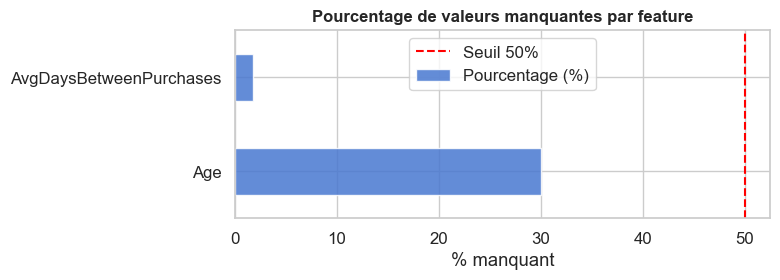

In [4]:
# Valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Manquants': missing,
    'Pourcentage (%)': missing_pct
}).query('Manquants > 0').sort_values('Pourcentage (%)', ascending=False)

print('\n--- Features avec valeurs manquantes ---')
display(missing_df)

# Visualisation
fig, ax = plt.subplots(figsize=(8, max(3, len(missing_df) * 0.5)))
missing_df['Pourcentage (%)'].plot(kind='barh', edgecolor='white', ax=ax, alpha=0.85)
ax.axvline(50, color='red', linestyle='--', label='Seuil 50%')
ax.set_title('Pourcentage de valeurs manquantes par feature',
             fontsize=12, fontweight='bold')
ax.set_xlabel('% manquant')
ax.legend()
plt.tight_layout()
plt.show()

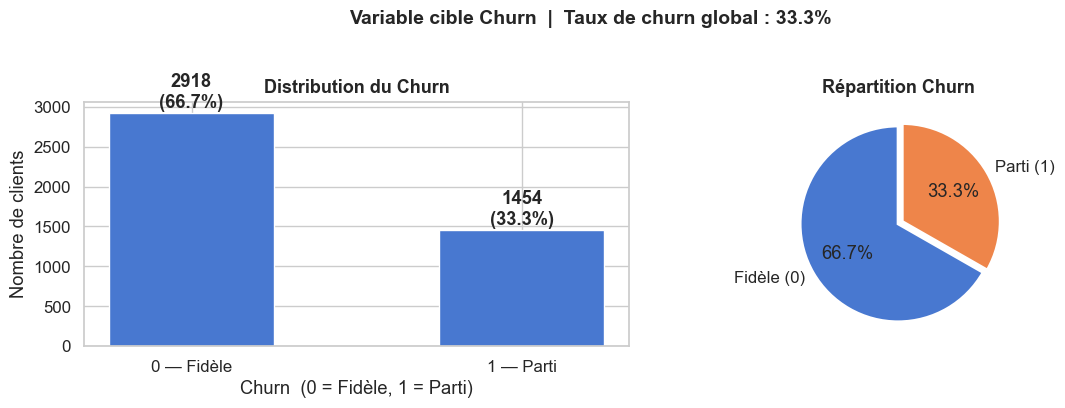

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Countplot ---
ax = axes[0]
churn_counts = df['Churn'].value_counts().sort_index()
bars = ax.bar(churn_counts.index.astype(str),
              churn_counts.values,
              edgecolor='white', width=0.5)
for bar, val in zip(bars, churn_counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            f'{val}\n({pct:.1f}%)',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Distribution du Churn', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn  (0 = Fidèle, 1 = Parti)')
ax.set_ylabel('Nombre de clients')
ax.set_xticks([0, 1])
ax.set_xticklabels(['0 — Fidèle', '1 — Parti'])

# --- Pie chart ---
axes[1].pie(churn_counts.values,
            labels=['Fidèle (0)', 'Parti (1)'],
            autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05),
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Répartition Churn', fontsize=13, fontweight='bold')

plt.suptitle(f'Variable cible Churn  |  Taux de churn global : '
             f"{df['Churn'].mean()*100:.1f}%",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

33 features numériques : ['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore']


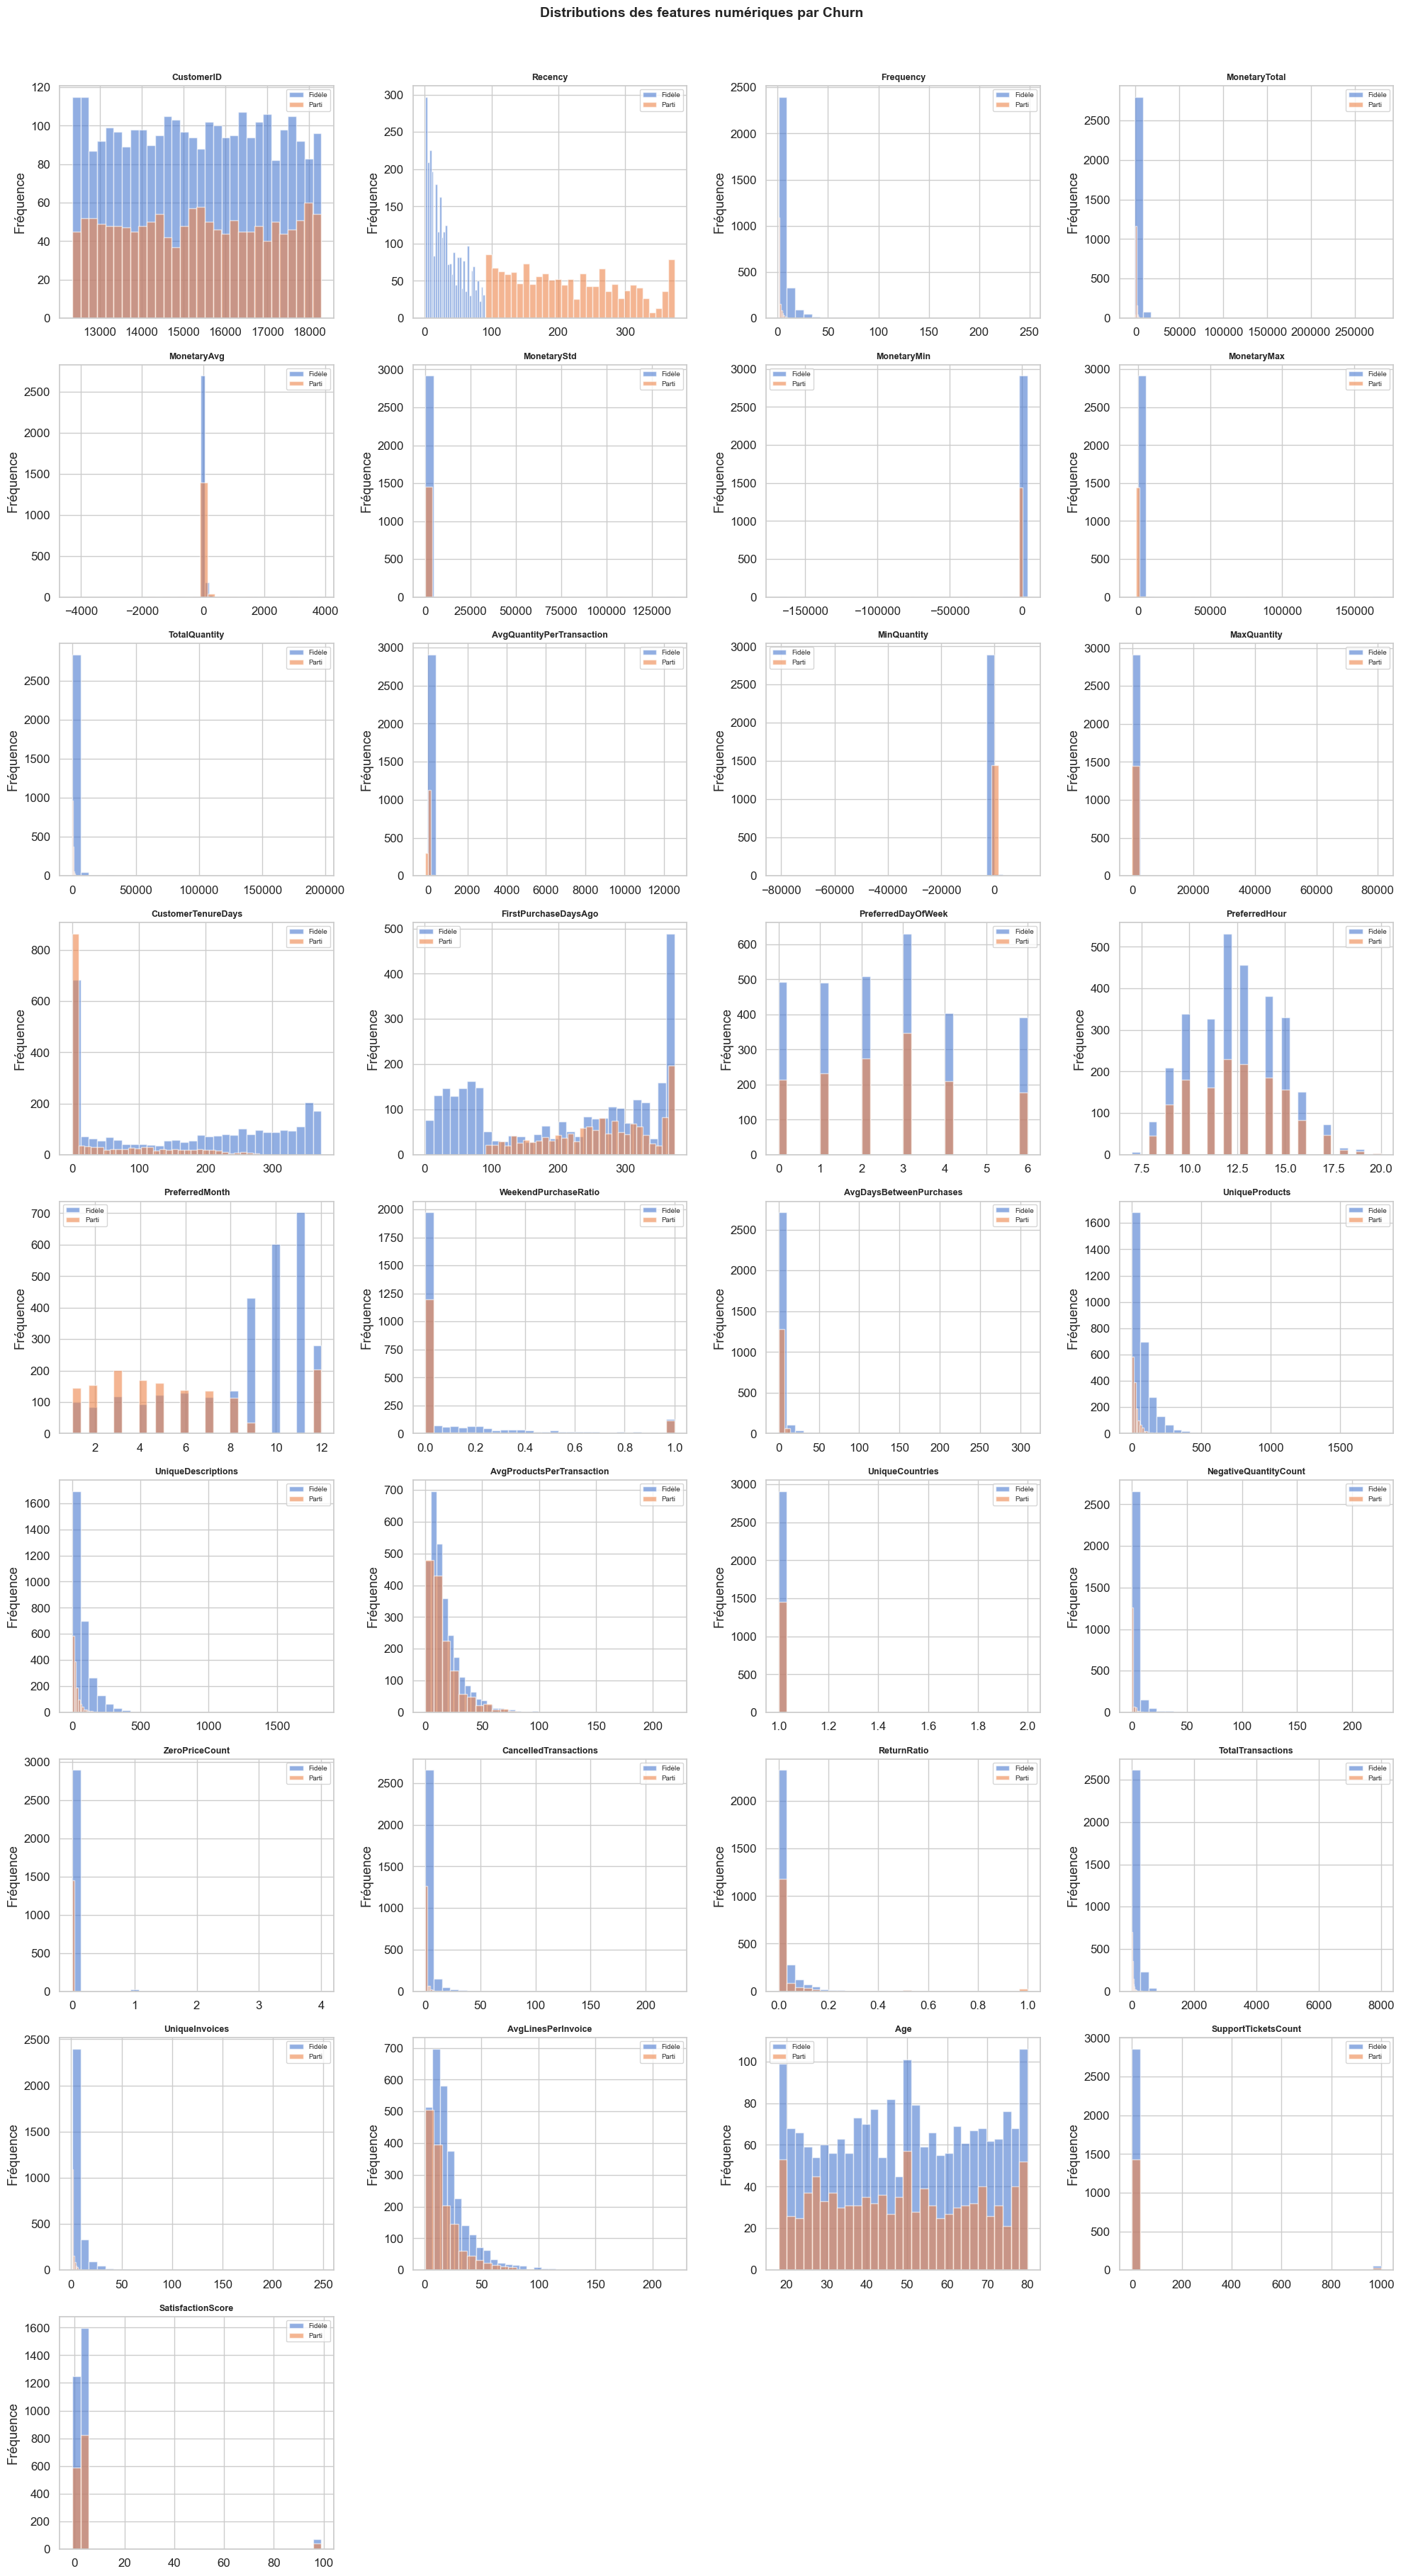

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'Churn']
print(f'{len(num_cols)} features numériques : {num_cols}')

n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data_0 = df[df['Churn'] == 0][col].dropna()
    data_1 = df[df['Churn'] == 1][col].dropna()
    axes[i].hist(data_0, bins=30, alpha=0.6,
                label='Fidèle', edgecolor='white')
    axes[i].hist(data_1, bins=30, alpha=0.6,
                 label='Parti', edgecolor='white')
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Fréquence')
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions des features numériques par Churn',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

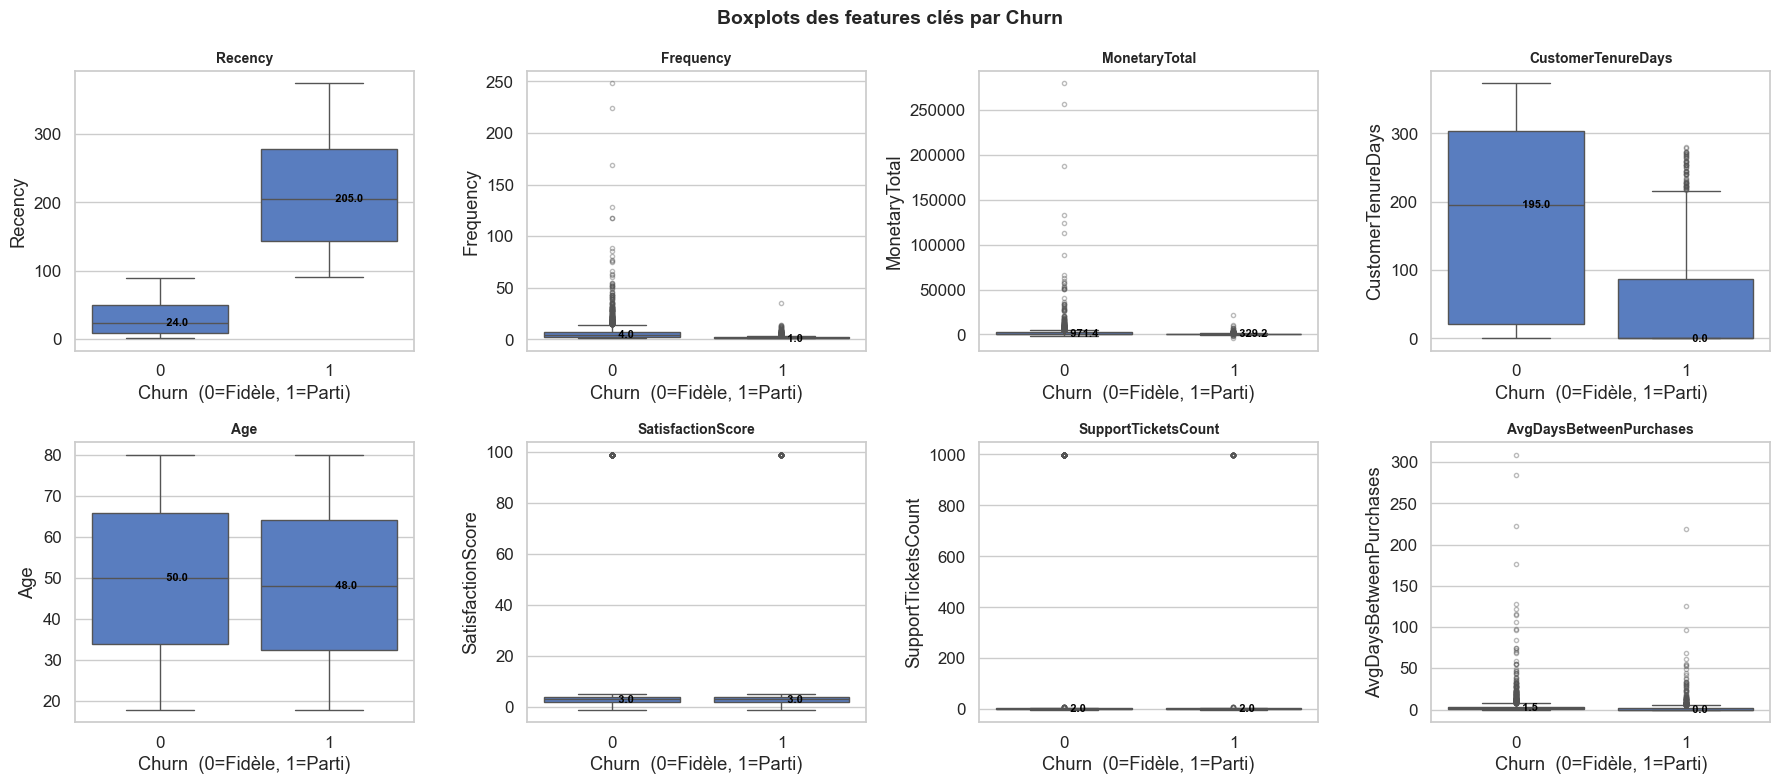

In [7]:
key_num = ['Recency', 'Frequency', 'MonetaryTotal', 'CustomerTenureDays',
           'Age', 'SatisfactionScore', 'SupportTicketsCount',
           'AvgDaysBetweenPurchases']

# Garder seulement celles présentes dans le df
key_num = [c for c in key_num if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(key_num):
    sns.boxplot(x='Churn', y=col, data=df,
                ax=axes[i],
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Churn  (0=Fidèle, 1=Parti)')
    # Médiane annotée
    for churn_val in [0, 1]:
        med = df[df['Churn'] == churn_val][col].median()
        axes[i].text(churn_val, med, f'  {med:.1f}',
                     va='center', fontsize=8, color='black', fontweight='bold')

plt.suptitle('Boxplots des features clés par Churn',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

18 features catégorielles : ['RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country']


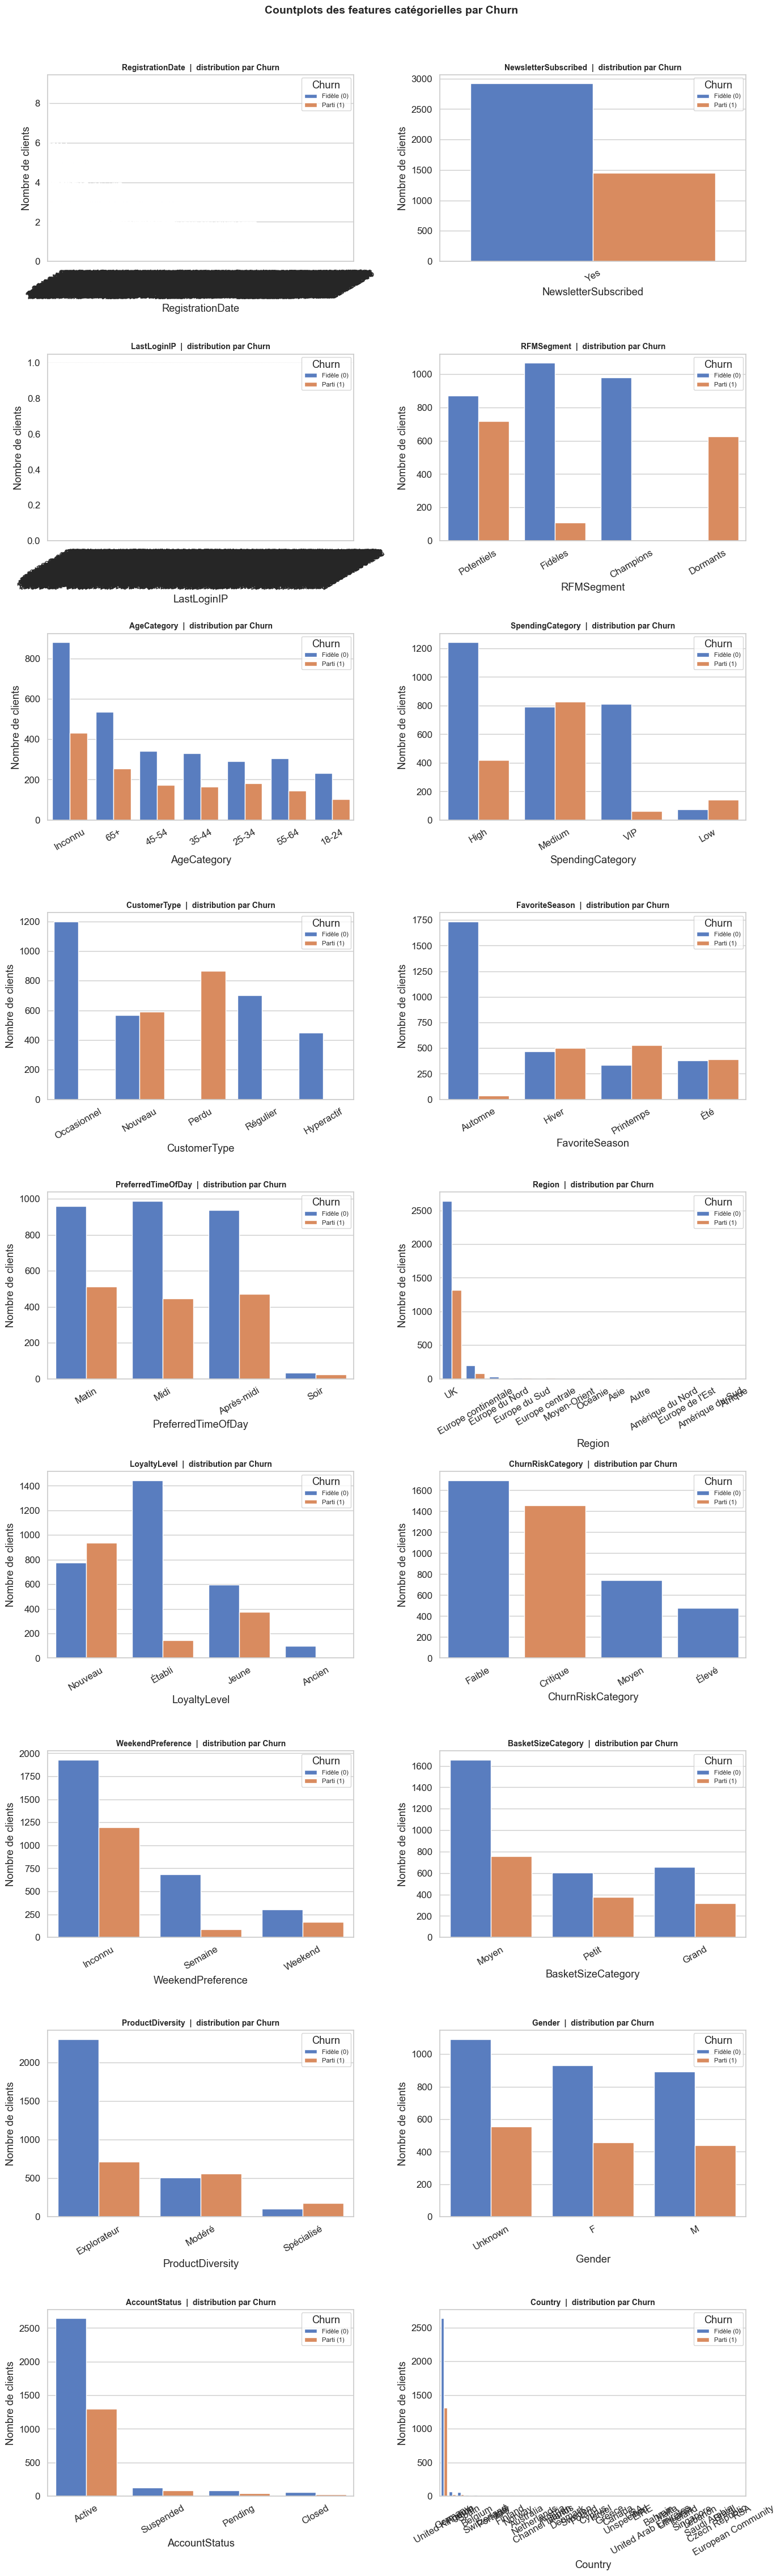

In [8]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'{len(cat_cols)} features catégorielles : {cat_cols}')

n_cols_plot = 2
n_rows_plot = (len(cat_cols) + 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                         figsize=(14, 5 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(x=col, hue='Churn', data=df, order=order,
                 ax=axes[i])
    axes[i].set_title(f'{col}  |  distribution par Churn',
                      fontsize=10, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Nombre de clients')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Churn', labels=['Fidèle (0)', 'Parti (1)'],
                   fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Countplots des features catégorielles par Churn',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

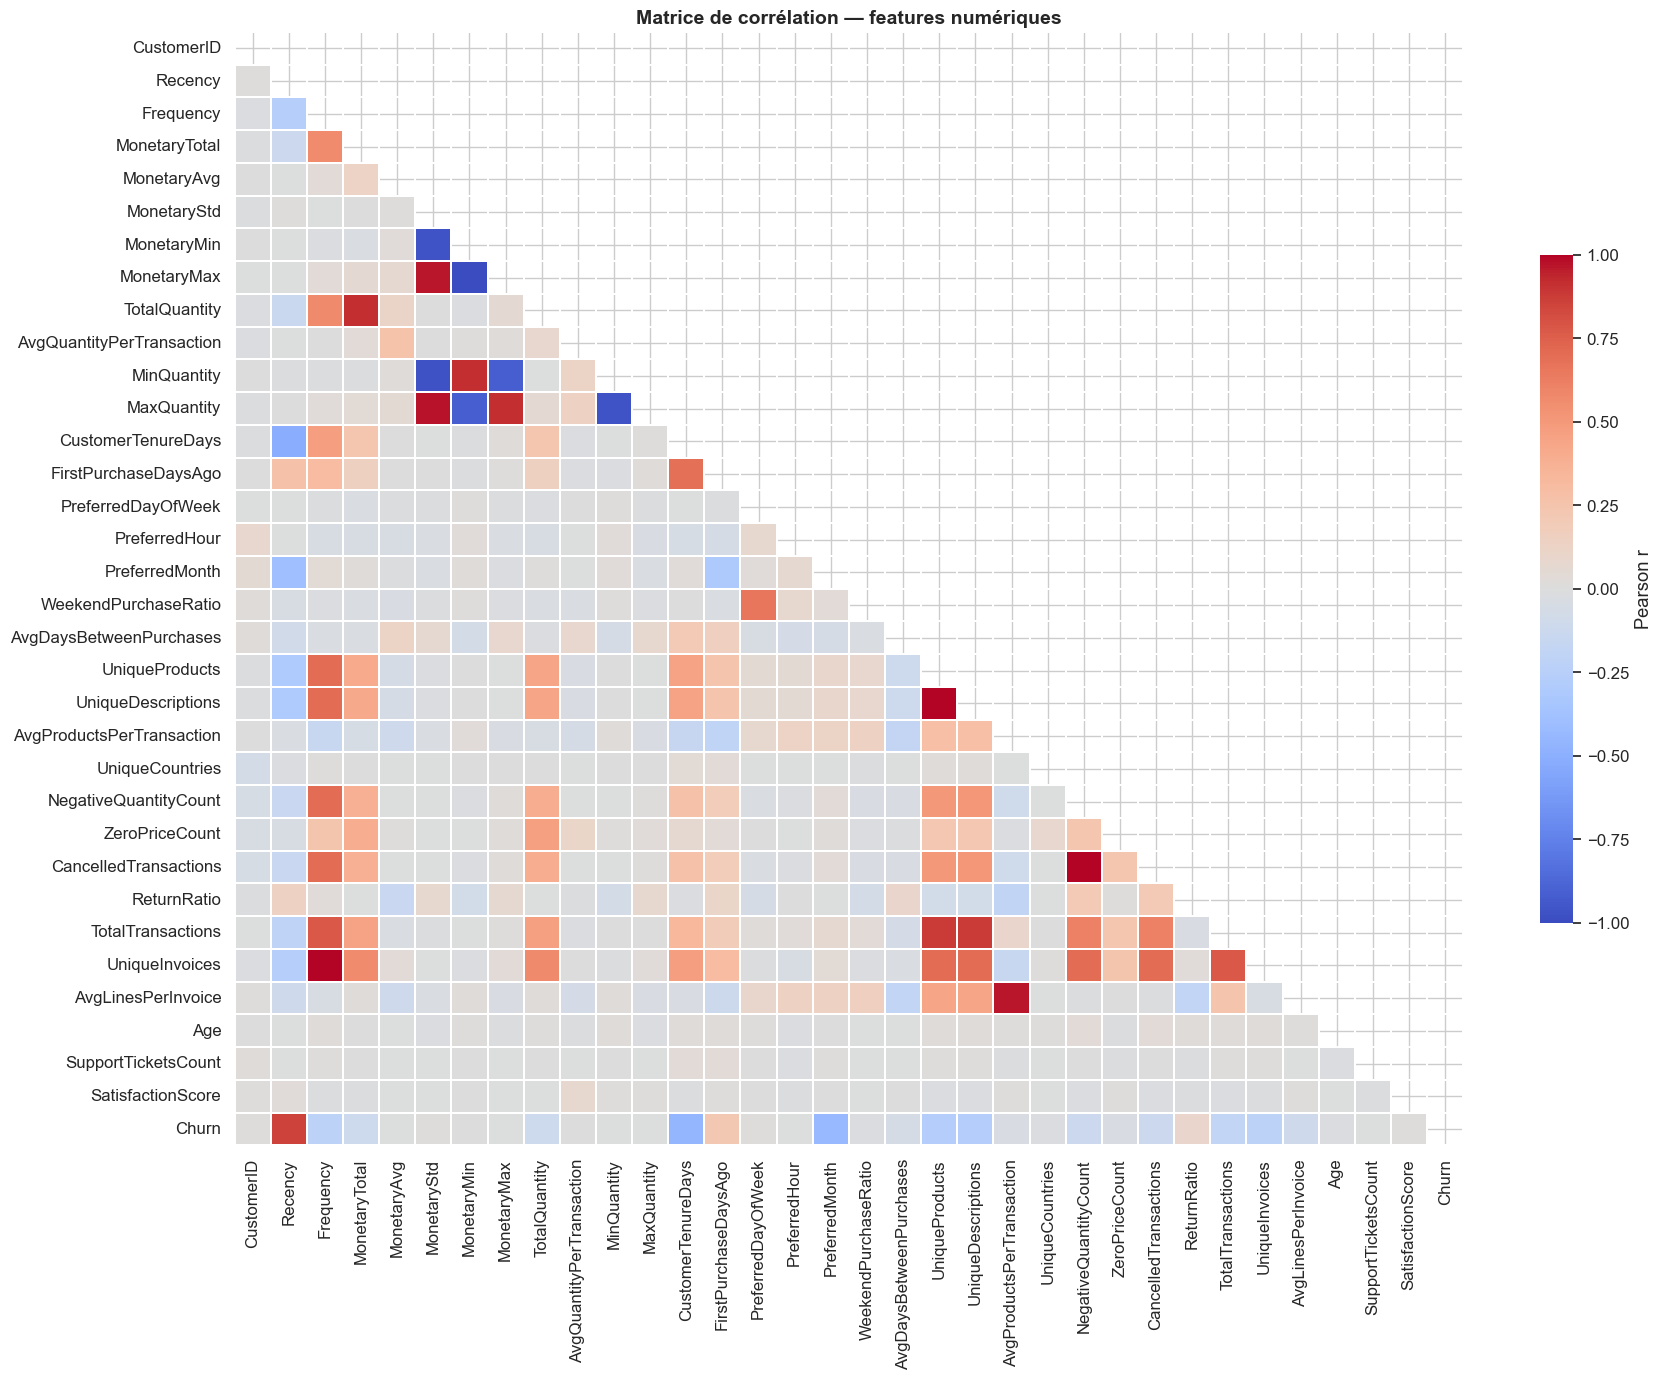

In [ ]:
# Imputation temporaire par médiane pour le calcul
df.info()  # pour vérifier les types et les colonnes avant corrélation
corr_cols = num_cols + ['Churn']
corr_matrix = (df[corr_cols]
               .fillna(df[corr_cols].median())
               .corr())

# Masque triangulaire supérieur
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr_matrix, mask=mask,
            cmap='coolwarm', center=0,
            vmin=-1, vmax=1,
            annot=len(corr_cols) <= 20,   # annot seulement si peu de cols
            fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, linecolor='white',
            ax=ax, cbar_kws={'shrink': 0.6, 'label': 'Pearson r'})
ax.set_title('Matrice de corrélation — features numériques',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

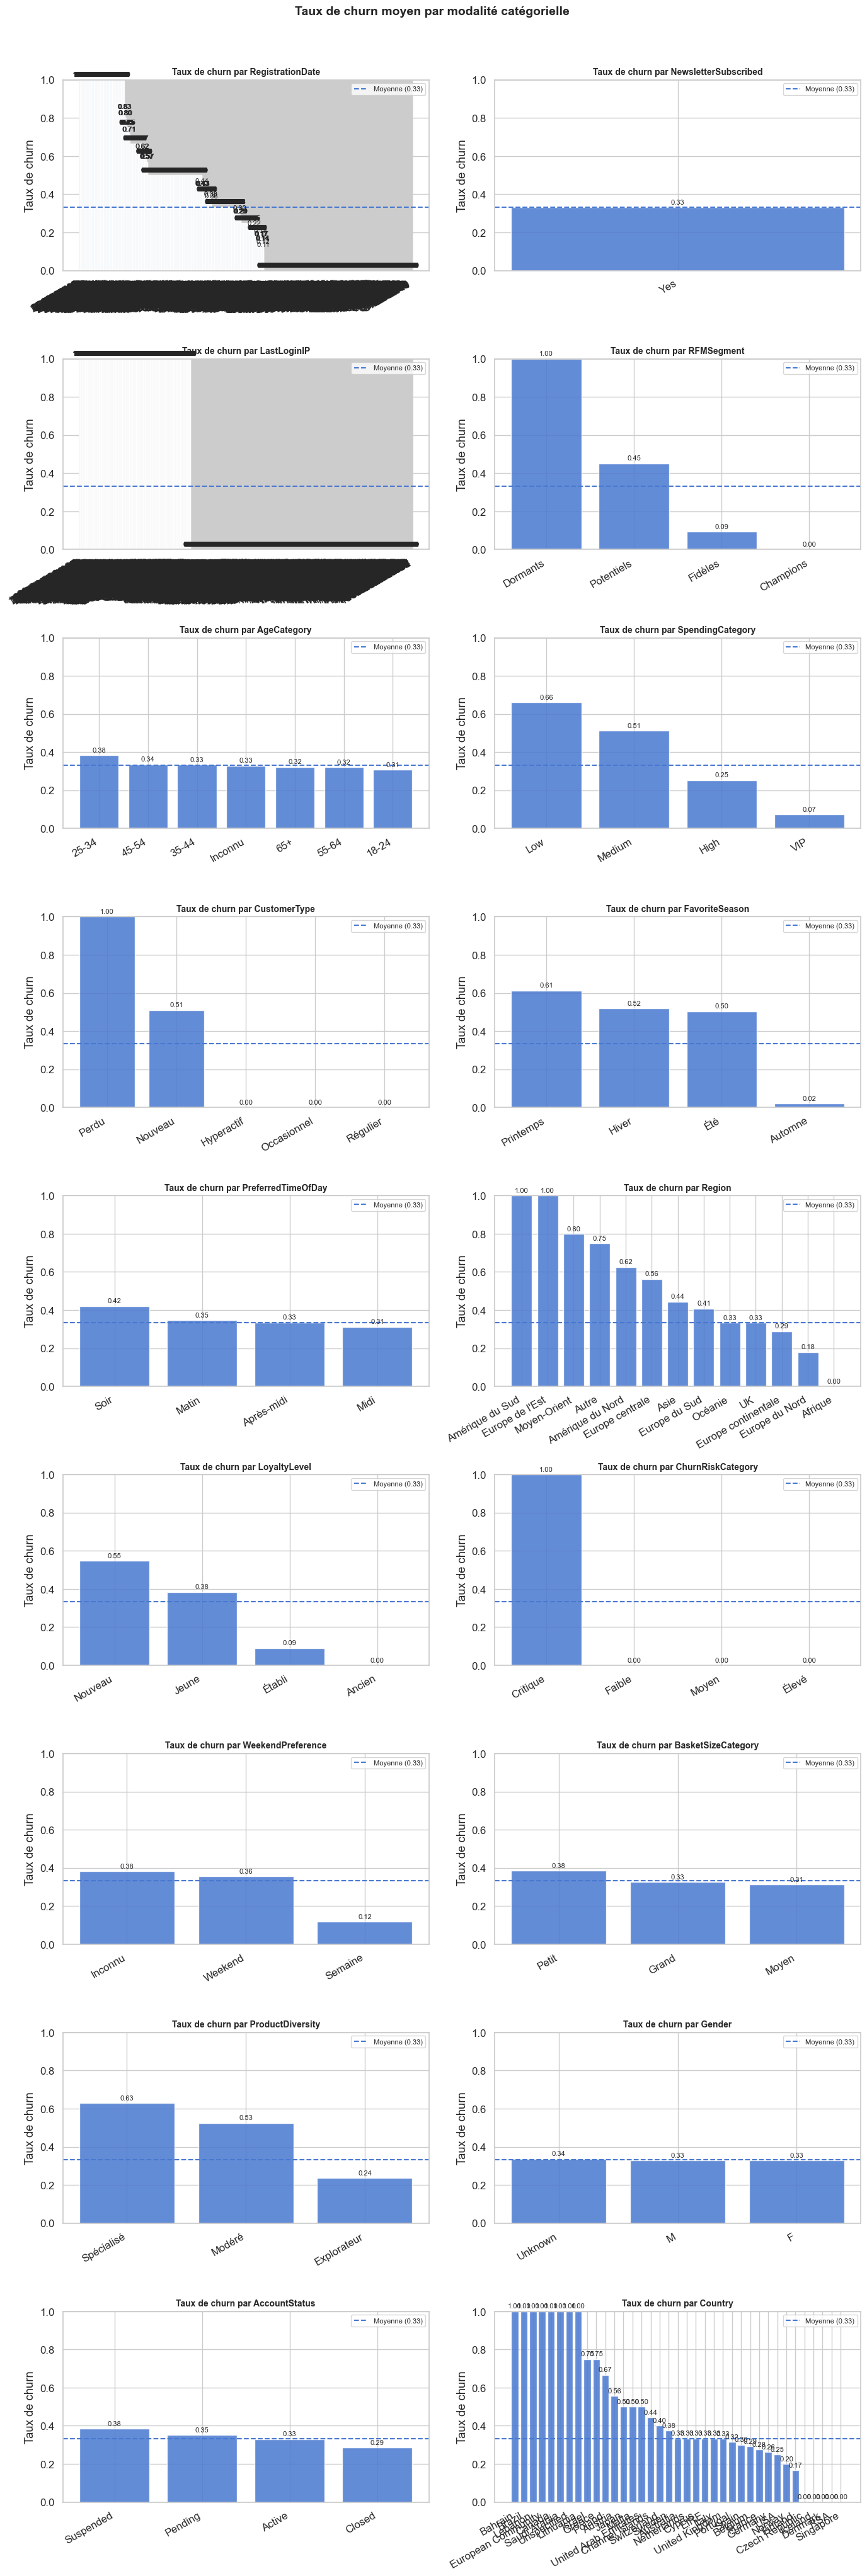

In [10]:
global_churn_rate = df['Churn'].mean()

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                         figsize=(14, 4.5 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = (df.groupby(col)['Churn'].mean()
                    .sort_values(ascending=False))
    bars = axes[i].bar(range(len(churn_rate)), churn_rate.values,
                     edgecolor='white', alpha=0.85)
    axes[i].set_xticks(range(len(churn_rate)))
    axes[i].set_xticklabels(churn_rate.index, rotation=30, ha='right')
    axes[i].axhline(global_churn_rate, linestyle='--',
                    linewidth=1.5,
                    label=f'Moyenne ({global_churn_rate:.2f})')
    axes[i].set_title(f'Taux de churn par {col}',
                      fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Taux de churn')
    axes[i].set_ylim(0, 1)
    axes[i].legend(fontsize=8)
    # Annotations valeurs
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.01,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Taux de churn moyen par modalité catégorielle',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

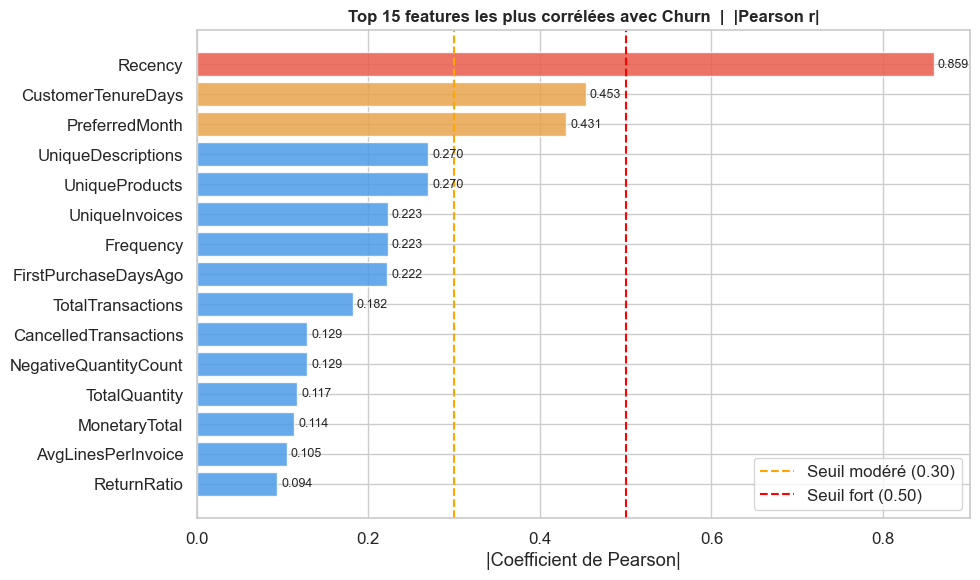

In [11]:
# Top corrélations avec Churn
churn_corr = (corr_matrix['Churn']
              .drop('Churn')
              .abs()
              .sort_values(ascending=True)
              .tail(15))

colors = [CHURN_PALETTE[1] if v > 0.5 else ORANGE if v > 0.3
          else BLUE
          for v in churn_corr.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(churn_corr.index, churn_corr.values,
               color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0.3, color='orange', linestyle='--', label='Seuil modéré (0.30)')
ax.axvline(0.5, color='red',    linestyle='--', label='Seuil fort (0.50)')
ax.set_title('Top 15 features les plus corrélées avec Churn  |  |Pearson r|',
             fontsize=12, fontweight='bold')
ax.set_xlabel('|Coefficient de Pearson|')
ax.legend()
for bar, val in zip(bars, churn_corr.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
# Paires fortement corrélées entre elles (|r| > 0.85)
corr_abs = corr_matrix.abs()
high_corr_pairs = []
for i in range(len(corr_abs.columns)):
    for j in range(i + 1, len(corr_abs.columns)):
        r = corr_abs.iloc[i, j]
        if r > 0.85:
            high_corr_pairs.append({
                'Feature A': corr_abs.columns[i],
                'Feature B': corr_abs.columns[j],
                '|r|': round(r, 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('|r|', ascending=False)
print(f'{len(high_corr_df)} paires avec |r| > 0.85')
display(high_corr_df)

18 paires avec |r| > 0.85


,Feature A,Feature B,|r|
1,Frequency,UniqueInvoices,1.0000
17,NegativeQuantityCount,CancelledTransactions,1.0000
13,UniqueProducts,UniqueDescriptions,0.9999
7,MonetaryMin,MonetaryMax,0.9939
5,MonetaryStd,MinQuantity,0.9740
6,MonetaryStd,MaxQuantity,0.9726
3,MonetaryStd,MonetaryMin,0.9673
4,MonetaryStd,MonetaryMax,0.9661
16,AvgProductsPerTransaction,AvgLinesPerInvoice,0.9632
12,MinQuantity,MaxQuantity,0.9612


In [13]:
# Résumé outliers par feature
outlier_summary = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'Feature': col,
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
        'Borne inf': round(lower, 2), 'Borne sup': round(upper, 2),
        'N outliers': n_out,
        '% outliers': round(n_out / df[col].notna().sum() * 100, 2)
    })

outlier_df = (pd.DataFrame(outlier_summary)
              .sort_values('N outliers', ascending=False))
display(outlier_df)

,Feature,Q1,Q3,Borne inf,Borne sup,N outliers,% outliers
17,WeekendPurchaseRatio,0.0000,0.0800,-0.1200,0.2100,833,19.0500
25,CancelledTransactions,0.0000,1.0000,-1.5000,2.5000,783,17.9100
23,NegativeQuantityCount,0.0000,1.0000,-1.5000,2.5000,783,17.9100
10,MinQuantity,-2.0000,2.0000,-8.0000,8.0000,771,17.6300
26,ReturnRatio,0.0000,0.0200,-0.0300,0.0500,623,14.2500
6,MonetaryMin,-11.5000,6.9600,-39.1900,34.6500,519,11.8700
4,MonetaryAvg,10.9900,23.5400,-7.8500,42.3800,505,11.5500
7,MonetaryMax,31.8000,102.0000,-73.5000,207.3000,501,11.4600
5,MonetaryStd,6.2300,20.6300,-15.3800,42.2400,482,11.0200
3,MonetaryTotal,293.3600,1611.7200,-1684.1800,3589.2700,423,9.6800


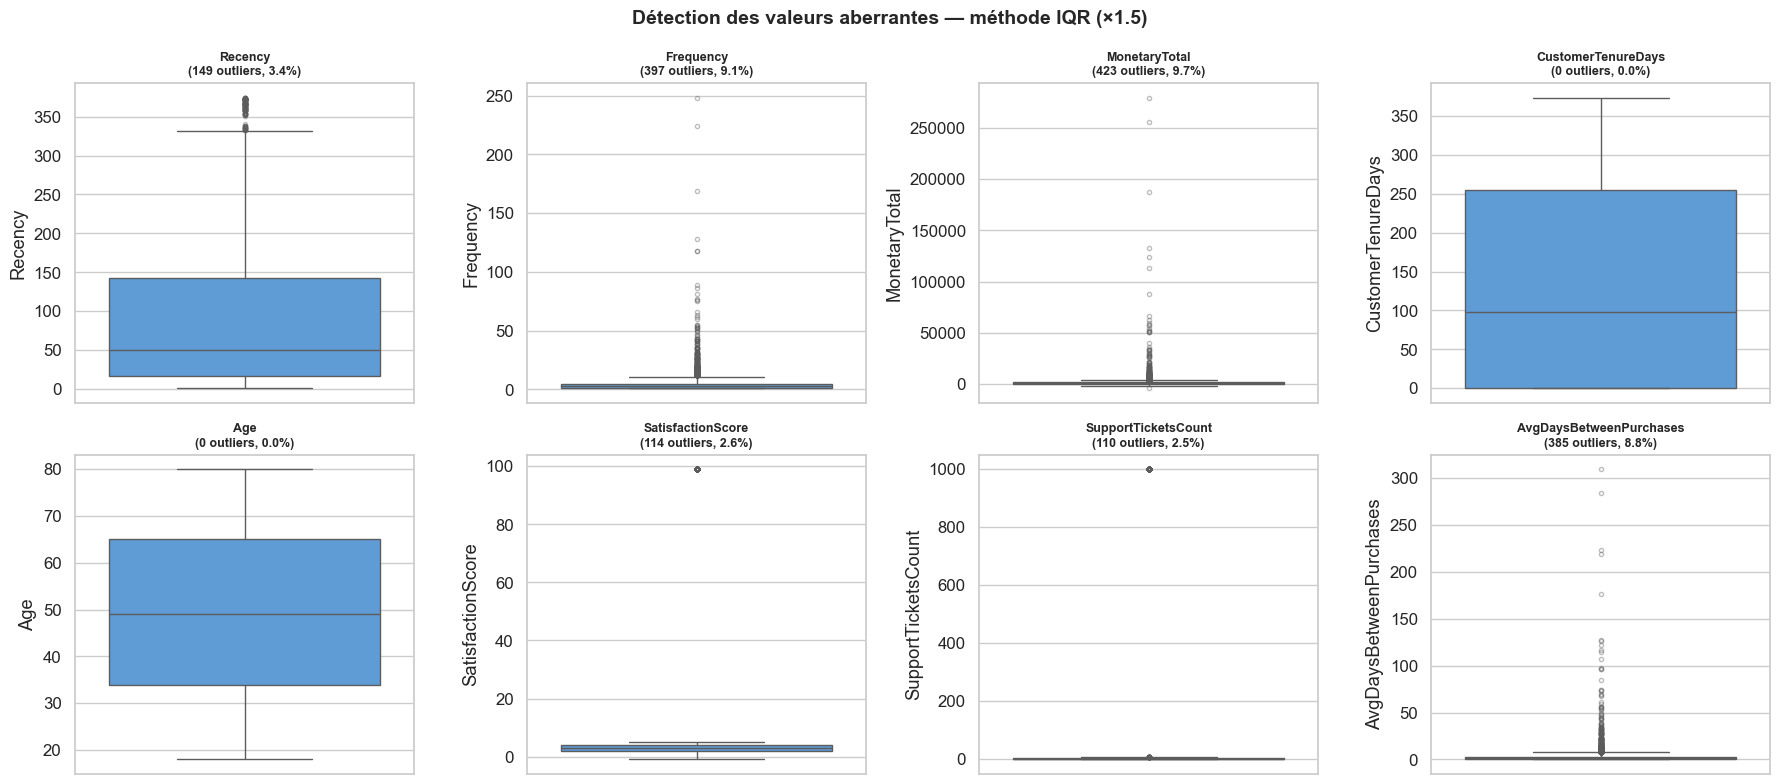

In [14]:
# Boxplots des features clés pour visualiser les outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(key_num):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()

    sns.boxplot(y=df[col], color=BLUE, ax=axes[i],
                flierprops=dict(marker='o', markersize=3,
                                alpha=0.4, color=CHURN_PALETTE[1]))
    axes[i].set_title(f'{col}\n({n_out} outliers, {n_out/len(df)*100:.1f}%)',
                      fontsize=9, fontweight='bold')

plt.suptitle('Détection des valeurs aberrantes — méthode IQR (×1.5)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Synthèse EDA

| Observation | Impact sur le pipeline |
|---|---|
| Taux de churn : **33,3%** (2:1) | SMOTE sur X_train nécessaire |
| `Recency` et `ChurnRiskCategory` : corrélations > 0.85 avec Churn | Prédicteurs clés à conserver |
| `Age` : ~30% de valeurs manquantes | KNN Imputer (k=5) |
| `SatisfactionScore` : ~8% NaN | Iterative Imputer |
| `NewsletterSubscribed` : variance nulle (100% "Yes") | Suppression immédiate |
| Nombreuses paires monétaires corrélées (|r| > 0.85) | Suppression des redondances en Étape 3 |
| Valeurs sentinelles : -1, 999, 99 dans tickets/satisfaction | Remplacement par NaN en Étape 2 |

---
## Étape 2 · Encoding + Feature engineering


In [15]:
# ── 1.2  Suppression feature constante ────────────────────────────────────────
df.drop(columns=['NewsletterSubscribed'], inplace=True)
print('✅  Dropped NewsletterSubscribed (variance = 0)')

✅  Dropped NewsletterSubscribed (variance = 0)


In [16]:
# ── 1.3  Parsing RegistrationDate → 4 features temporelles ───────────────────
#
#  Problème : formats inconsistants dans la colonne brute
#    - UK  : "17/07/10"  (DD/MM/YY)
#    - ISO : "2010-10-04"
#    - US  : "09/23/2010" (MM/DD/YYYY)
#
#  Solution : pd.to_datetime avec dayfirst=True (priorité UK) + errors='coerce'

df['RegistrationDate'] = pd.to_datetime(
    df['RegistrationDate'],
    dayfirst=True,   # priorité format UK (DD/MM)
    errors='coerce'  # NaT si format non reconnu
)

df['RegYear']    = df['RegistrationDate'].dt.year
df['RegMonth']   = df['RegistrationDate'].dt.month
df['RegDay']     = df['RegistrationDate'].dt.day
df['RegWeekday'] = df['RegistrationDate'].dt.weekday  # 0=Lundi, 6=Dimanche

df.drop(columns=['RegistrationDate'], inplace=True)
print('✅  RegistrationDate → RegYear, RegMonth, RegDay, RegWeekday')

✅  RegistrationDate → RegYear, RegMonth, RegDay, RegWeekday


In [17]:
# ── 1.4  Parsing LastLoginIP → 2 features réseau ──────────────────────────────
#
#  Feature engineering depuis une IP brute :
#    - IP_IsPrivate  : 1 si RFC-1918 (10.x, 172.16-31.x, 192.168.x)  0 sinon
#    - IP_FirstOctet : premier octet (proxy de plage réseau)

def ip_is_private(ip_str: str) -> int:
    if not isinstance(ip_str, str):
        return -1
    parts = ip_str.strip().split('.')
    if len(parts) != 4:
        return -1
    try:
        a, b = int(parts[0]), int(parts[1])
    except ValueError:
        return -1
    if a == 10:
        return 1
    if a == 172 and 16 <= b <= 31:
        return 1
    if a == 192 and b == 168:
        return 1
    return 0

def ip_first_octet(ip_str: str):
    if not isinstance(ip_str, str):
        return np.nan
    try:
        return int(ip_str.strip().split('.')[0])
    except (ValueError, IndexError):
        return np.nan

df['IP_IsPrivate']  = df['LastLoginIP'].apply(ip_is_private)
df['IP_FirstOctet'] = df['LastLoginIP'].apply(ip_first_octet)
df.drop(columns=['LastLoginIP'], inplace=True)
print('✅  LastLoginIP → IP_IsPrivate, IP_FirstOctet')

✅  LastLoginIP → IP_IsPrivate, IP_FirstOctet


In [18]:
# ── 1.5  Correction valeurs aberrantes ────────────────────────────────────────

# SupportTicketsCount : -1 (sentinel inconnu) et 999 (erreur saisie) → NaN
df['SupportTicketsCount'] = df['SupportTicketsCount'].replace([-1, 999], np.nan)

# SatisfactionScore   : -1 (inconnu), 0 (hors échelle 1-5), 99 (erreur) → NaN
df['SatisfactionScore']   = df['SatisfactionScore'].replace([-1, 0, 99], np.nan)

print('✅  Aberrant values corrected → NaN')

✅  Aberrant values corrected → NaN


In [19]:
# ── 1.6  Encodage Ordinal ─────────────────────────────────────────────────────
#
#  Les features ordinals ont un ORDRE naturel → entiers séquentiels

ordinal_maps = {
    'AgeCategory': {
        'Inconnu': 0, '18-24': 1, '25-34': 2,
        '35-44': 3,  '45-54': 4, '55-64': 5, '65+': 6
    },
    'SpendingCategory':  {'Low': 1, 'Medium': 2, 'High': 3, 'VIP': 4},
    'LoyaltyLevel':      {'Nouveau': 1, 'Jeune': 2, 'Établi': 3, 'Ancien': 4},
    'ChurnRiskCategory': {'Faible': 1, 'Moyen': 2, 'Élevé': 3, 'Critique': 4},
    'BasketSizeCategory':{'Inconnu': 0, 'Petit': 1, 'Moyen': 2, 'Grand': 3},
    'PreferredTimeOfDay':{'Nuit': 0, 'Matin': 1, 'Midi': 2, 'Après-midi': 3, 'Soir': 4},
}

for col, mapping in ordinal_maps.items():
    df[col] = df[col].map(mapping)

print(f'✅  Ordinal encoding : {len(ordinal_maps)} features')

✅  Ordinal encoding : 6 features


In [20]:
# ── 1.7  One-Hot Encoding ─────────────────────────────────────────────────────
#
#  Les features nominales (sans ordre) → variables binaires k-1
#  drop_first=True évite le piège de la multicolinéarité parfaite

ohe_features = [
    'RFMSegment', 'CustomerType', 'FavoriteSeason',
    'WeekendPreference', 'ProductDiversity', 'Gender',
    'AccountStatus', 'Region'
]

df = pd.get_dummies(
    df, columns=ohe_features,
    prefix=ohe_features,
    drop_first=True,
    dtype=int
)

n_ohe = sum(1 for c in df.columns if any(c.startswith(f+'_') for f in ohe_features))
print(f'✅  One-Hot Encoding : {len(ohe_features)} features → {n_ohe} colonnes binaires')

✅  One-Hot Encoding : 8 features → 31 colonnes binaires


In [21]:
# ── 1.8  Target Encoding — Country (37+ niveaux) ──────────────────────────────
#
#  Country a trop de niveaux pour OHE → on remplace par le taux de churn moyen
#  par pays (encodage supervisé)

country_churn_map = df.groupby('Country')['Churn'].mean()
df['Country_TargetEnc'] = df['Country'].map(country_churn_map)
df.drop(columns=['Country'], inplace=True)
print('✅  Country → Country_TargetEnc (taux churn moyen par pays)')

✅  Country → Country_TargetEnc (taux churn moyen par pays)


In [22]:
# ── 1.9  Suppression CustomerID ───────────────────────────────────────────────
df.drop(columns=['CustomerID'], inplace=True)
print(f'✅  Dropped CustomerID (identifiant unique — pas prédictif)')

✅  Dropped CustomerID (identifiant unique — pas prédictif)


In [23]:
# ── 1.10  Feature Engineering ─────────────────────────────────────────────────
#
#  Création de 10 features dérivées pour capturer des signaux business
#  que les features brutes n'expriment pas directement.

# 1. Intensité de dépense (£ / jour depuis dernier achat)
df['MonetaryPerDay']      = df['MonetaryTotal'] / (df['Recency'] + 1)

# 2. Valeur du panier moyen
df['AvgBasketValue']      = df['MonetaryTotal'] / df['Frequency'].replace(0, np.nan)

# 3. Ratio Recency / Tenure : élevé = inactif malgré ancienneté
df['TenureRecencyRatio']  = df['Recency'] / (df['CustomerTenureDays'] + 1)

# 4. Taux d'annulation normalisé par fréquence
df['CancelPerFreq']       = df['CancelledTransactions'] / (df['Frequency'] + 1)

# 5. Part de la commande max dans le total
df['MaxOrderShare']       = df['MonetaryMax'] / (df['MonetaryTotal'].abs() + 1)

# 6. Charge support / durée relation
df['SupportBurden']       = df['SupportTicketsCount'] / (df['CustomerTenureDays'] + 1)

# 7. Largeur produits par transaction
df['ProdBreadthPerTrans'] = df['UniqueProducts'] / (df['Frequency'] + 1)

# 8. Flag : client récent (tenure < 90 jours)
df['IsNewCustomer']       = (df['CustomerTenureDays'] < 90).astype(int)

# 9. Flag : fort taux d'annulation (> 10% des transactions)
df['HighCancelFlag']      = (
    (df['CancelledTransactions'] / (df['TotalTransactions'] + 1)) > 0.10
).astype(int)

# 10. Ancienneté compte (années depuis inscription, référence 2011)
df['RegYearsActive']      = 2011 - df['RegYear'].fillna(2010)

print('✅  10 nouvelles features créées')
print(f'Shape total après feature engineering : {df.shape}')

✅  10 nouvelles features créées
Shape total après feature engineering : (4372, 87)


---
## Étape 2 · Matrice de Corrélation — Vue Complète (87 features)


In [24]:
# ── Séparer X et y avant tout ─────────────────────────────────────────────────
X_full = df.drop(columns=['Churn'])
y      = df['Churn'].copy()

print(f'Features totales avant sélection : {X_full.shape[1]}')
print(f'Samples                          : {X_full.shape[0]:,}')

Features totales avant sélection : 86
Samples                          : 4,372


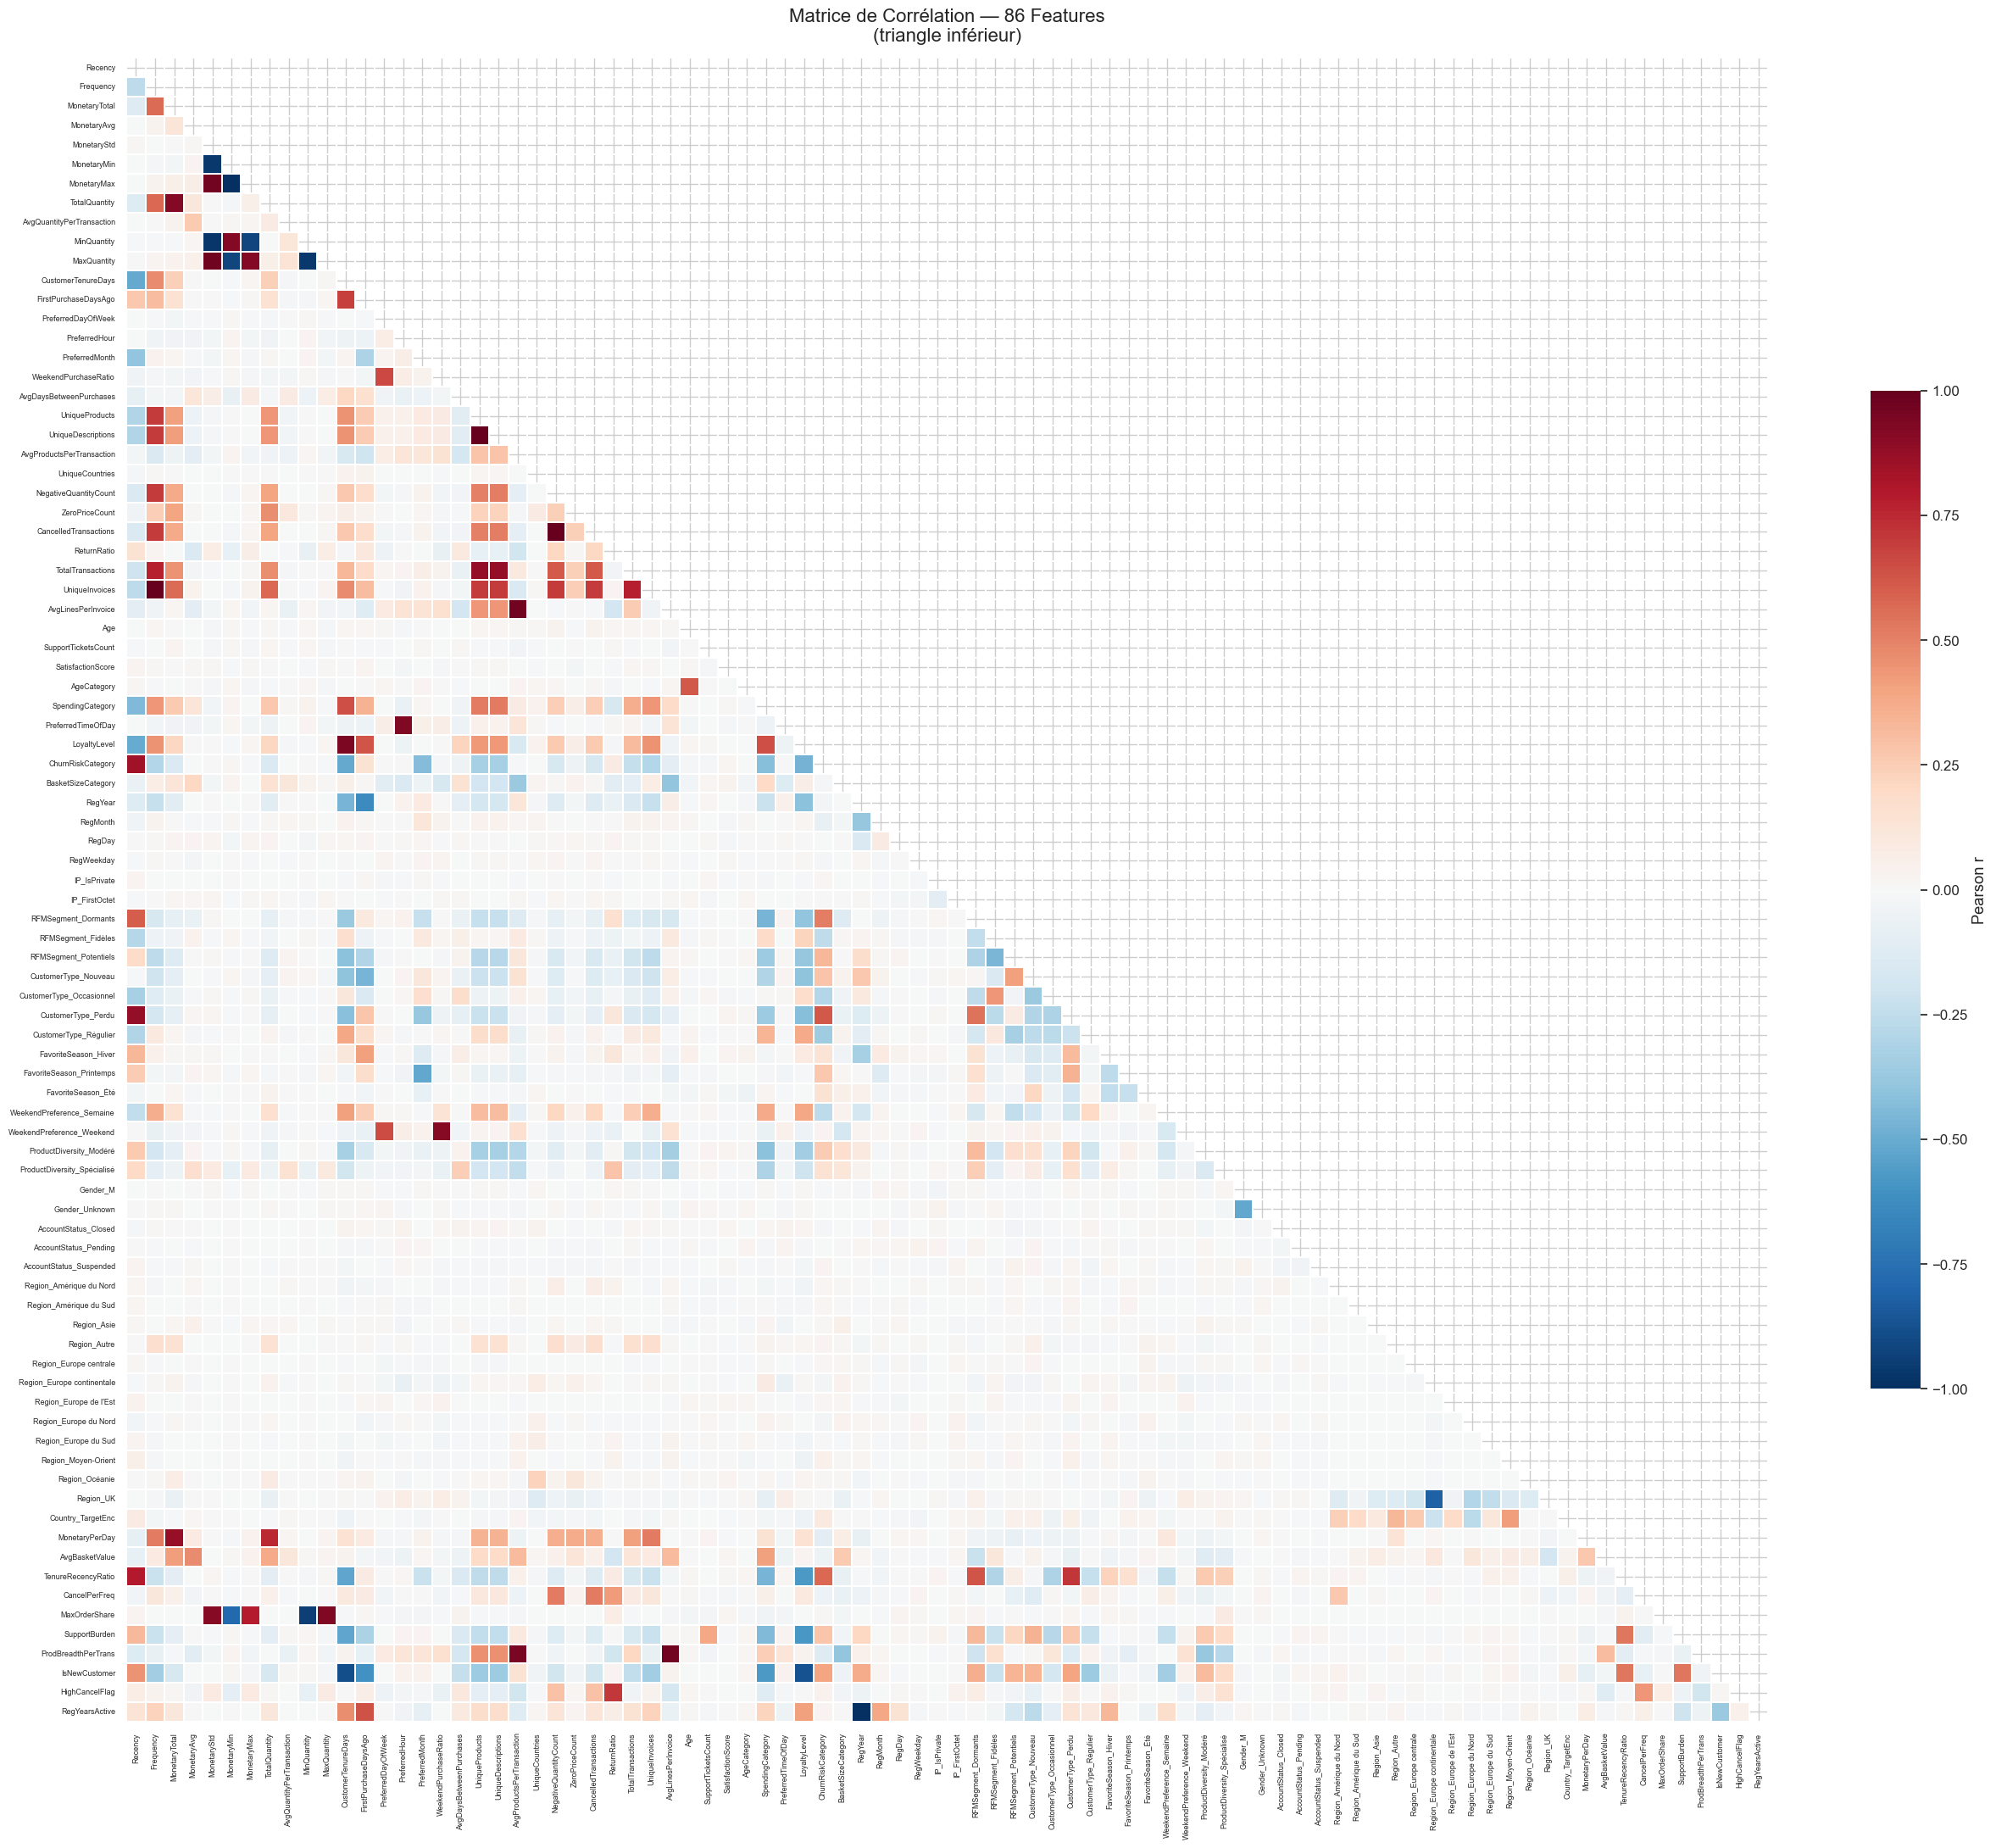

📊  Sauvegardé : reports/corr_matrix_full_87features.png


In [25]:
# ── Remplissage temporaire des NaN pour calculer la corrélation ───────────────
# (imputation définitive se fera plus tard, après le split)
X_corr = X_full.fillna(X_full.median(numeric_only=True))

corr_matrix = X_corr.corr()

# ── Heatmap complète ──────────────────────────────────────────────────────────
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(26, 22))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.15,
    ax=ax,
    cbar_kws={'shrink': 0.6, 'label': 'Pearson r'}
)
ax.set_title(f'Matrice de Corrélation — {X_full.shape[1]} Features\n(triangle inférieur)',
             fontsize=16, pad=14)
ax.tick_params(axis='x', labelsize=6.5, rotation=90)
ax.tick_params(axis='y', labelsize=6.5)
plt.tight_layout()
plt.show()


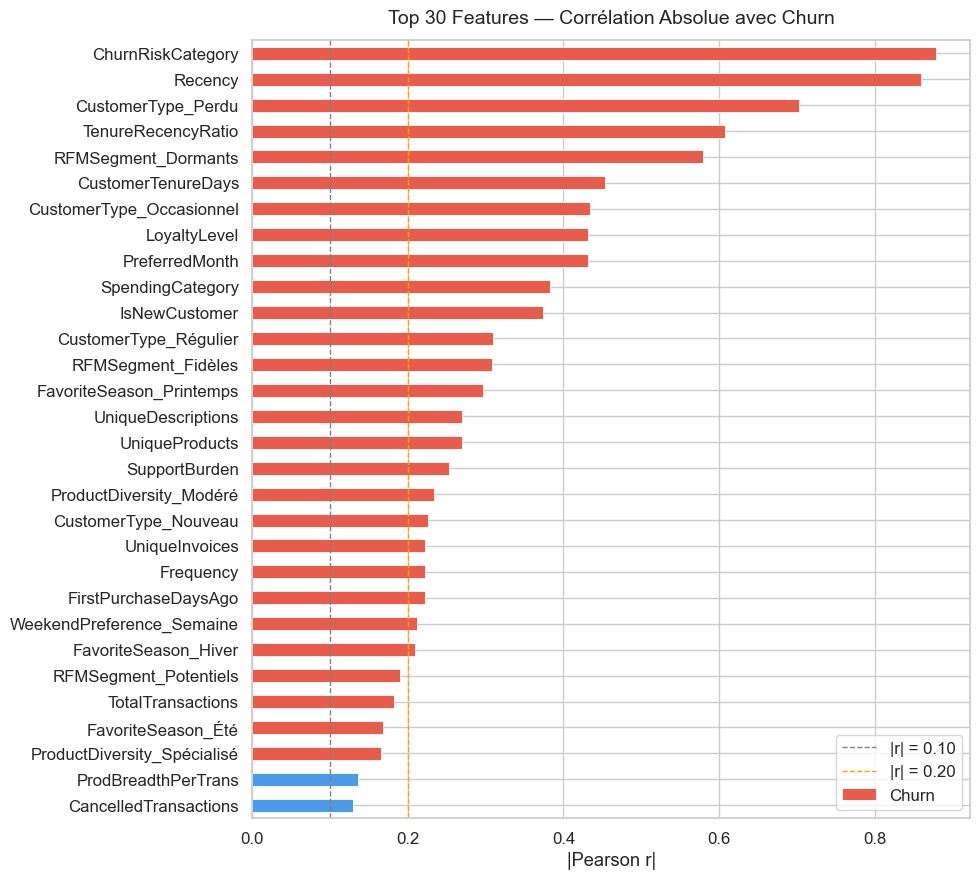

Top 10 features les plus corrélées avec Churn :
                            |r|
ChurnRiskCategory        0.8789
Recency                  0.8590
CustomerType_Perdu       0.7031
TenureRecencyRatio       0.6071
RFMSegment_Dormants      0.5797
CustomerTenureDays       0.4535
CustomerType_Occasionnel 0.4337
LoyaltyLevel             0.4314
PreferredMonth           0.4309
SpendingCategory         0.3829


In [26]:
# ── Corrélation avec la target ────────────────────────────────────────────────
X_corr_with_y = X_corr.copy()
X_corr_with_y['Churn'] = y

target_corr = X_corr_with_y.corr()['Churn'].drop('Churn').abs()
target_corr_sorted = target_corr.sort_values(ascending=False)

# Barplot top 30
top30 = target_corr_sorted.head(30)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#E85C4C' if target_corr_sorted[c] > 0.15 else '#4C9BE8'
          for c in top30.index]
top30.plot(kind='barh', color=colors, ax=ax, edgecolor='white', linewidth=0.6)
ax.axvline(0.10, color='gray', linestyle='--', linewidth=1, label='|r| = 0.10')
ax.axvline(0.20, color='orange', linestyle='--', linewidth=1, label='|r| = 0.20')
ax.set_title('Top 30 Features — Corrélation Absolue avec Churn', fontsize=14, pad=12)
ax.set_xlabel('|Pearson r|')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 features les plus corrélées avec Churn :')
print(target_corr_sorted.head(10).to_frame('|r|').round(4))

---
## Étape 3 · Sélection de Features — 4 Critères de Suppression

### 3-A · Critère 1 — Variance Nulle

In [27]:
# ── Détection automatique via VarianceThreshold ───────────────────────────────
# threshold=0 : supprime uniquement les features à variance STRICTEMENT nulle

vt = VarianceThreshold(threshold=0.0)
vt.fit(X_corr)  # on utilise la version sans NaN pour le calcul

zero_var_mask  = ~vt.get_support()
zero_var_cols  = X_full.columns[zero_var_mask].tolist()

print(f'Features à variance nulle : {len(zero_var_cols)}')
if zero_var_cols:
    for c in zero_var_cols:
        print(f'  → {c}  (valeurs uniques : {X_full[c].unique()[:5]})')
else:
    print('  ✅  Aucune feature à variance nulle détectée après encodage')
    print('  (NewsletterSubscribed a déjà été supprimée à l\'étape 1.2)')

Features à variance nulle : 0
  ✅  Aucune feature à variance nulle détectée après encodage
  (NewsletterSubscribed a déjà été supprimée à l'étape 1.2)


### 3-B · Critère 2 — Valeurs Manquantes > 50 %

In [28]:
missing_pct = X_full.isnull().mean() * 100
high_missing_cols = missing_pct[missing_pct > 50].index.tolist()

print(f'Features avec > 50% de valeurs manquantes : {len(high_missing_cols)}')
if high_missing_cols:
    print(missing_pct[high_missing_cols].to_frame('% manquant').round(2))
else:
    print('  ✅  Aucune feature ne dépasse le seuil de 50%')

# Résumé des features avec des NaN
print('\nRécapitulatif des valeurs manquantes (features affectées) :')
mv = missing_pct[missing_pct > 0].sort_values(ascending=False)
print(mv.to_frame('% manquant').round(2))

Features avec > 50% de valeurs manquantes : 0
  ✅  Aucune feature ne dépasse le seuil de 50%

Récapitulatif des valeurs manquantes (features affectées) :
                         % manquant
Age                         29.9900
SatisfactionScore            7.9800
SupportTicketsCount          2.9700
SupportBurden                2.9700
AvgDaysBetweenPurchases      1.8100


### 3-C · Critère 3 — Forte Corrélation (Multicolinéarité, |r| > 0.85)

In [29]:
# ── Détection des paires fortement corrélées ──────────────────────────────────
CORR_THRESHOLD = 0.85

corr_abs = corr_matrix.abs()
upper_tri = corr_abs.where(
    np.triu(np.ones_like(corr_abs, dtype=bool), k=1)
)

# Toutes les paires au-dessus du seuil
high_corr_pairs = [
    (col, row, upper_tri.at[row, col])
    for col in upper_tri.columns
    for row in upper_tri.index
    if upper_tri.at[row, col] > CORR_THRESHOLD
]
high_corr_pairs.sort(key=lambda x: x[2], reverse=True)

print(f'Paires avec |r| > {CORR_THRESHOLD} : {len(high_corr_pairs)}\n')
print(f'{"Feature A":45s}  {"Feature B":45s}  r')
print('-' * 100)
for a, b, r in high_corr_pairs:
    print(f'{a:45s}  {b:45s}  {r:.3f}')

Paires avec |r| > 0.85 : 30

Feature A                                      Feature B                                      r
----------------------------------------------------------------------------------------------------
CancelledTransactions                          NegativeQuantityCount                          1.000
UniqueInvoices                                 Frequency                                      1.000
RegYearsActive                                 RegYear                                        1.000
UniqueDescriptions                             UniqueProducts                                 1.000
MonetaryMax                                    MonetaryMin                                    0.994
MinQuantity                                    MonetaryStd                                    0.974
MaxQuantity                                    MonetaryStd                                    0.973
MonetaryMin                                    MonetaryStd                

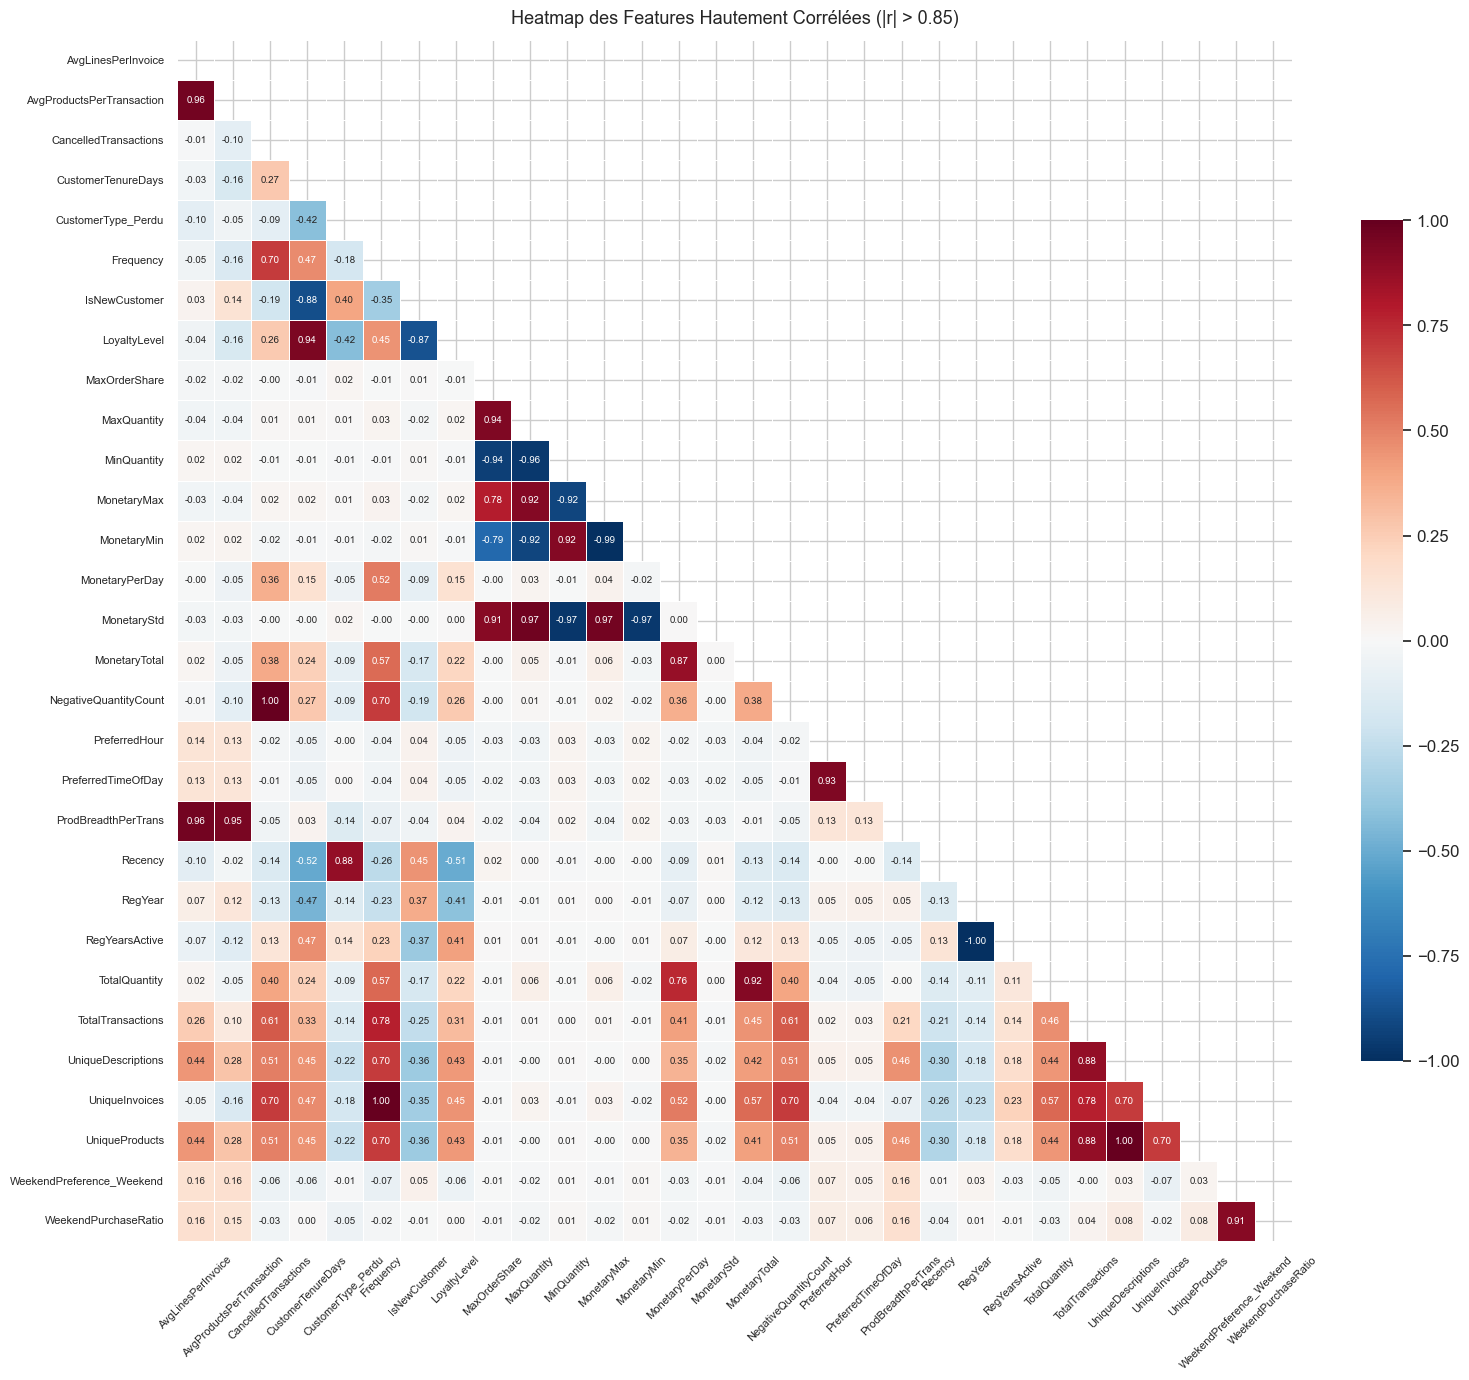

In [30]:
# ── Heatmap des paires hautement corrélées ────────────────────────────────────
high_corr_features = list(set(
    [a for a, b, r in high_corr_pairs] +
    [b for a, b, r in high_corr_pairs]
))
high_corr_features.sort()

fig, ax = plt.subplots(figsize=(16, 14))
sub_corr = corr_matrix.loc[high_corr_features, high_corr_features]
mask_sub = np.triu(np.ones_like(sub_corr, dtype=bool))
sns.heatmap(
    sub_corr, mask=mask_sub,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax,
    cbar_kws={'shrink': 0.7}
)
ax.set_title(f'Heatmap des Features Hautement Corrélées (|r| > {CORR_THRESHOLD})',
             fontsize=13, pad=12)
ax.tick_params(axis='x', labelsize=8, rotation=45)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

In [31]:
# ── Stratégie de suppression basée sur le sens métier ────────────────────────
#
# Pour chaque paire (A, B) avec |r|>0.85 on garde celle qui a le plus de
# sens métier / la plus large variance d'information :
#
# KEEP                       DROP                      RAISON
# CancelledTransactions   ← NegativeQuantityCount     Cancellations plus direct
# Frequency               ← UniqueInvoices            Frequency est la def RFM
# RegYearsActive          ← RegYear                   Feature dérivée plus utile
# UniqueProducts          ← UniqueDescriptions        UniqueProducts suffit
# MonetaryStd             ← MonetaryMin, MonetaryMax  Std capture la variance
# AvgProductsPerTrans     ← ProdBreadthPerTrans       Déjà dans les engineered
# AvgProductsPerTrans     ← AvgLinesPerInvoice        Redondant avec ci-dessus
# CustomerTenureDays      ← LoyaltyLevel              Numérique > catégoriel
# CustomerTenureDays      ← IsNewCustomer             Redondant (dérivé de tenure)
# PreferredHour           ← PreferredTimeOfDay        Heure > catégorie agrégée
# MonetaryTotal           ← TotalQuantity             Valeur £ > volume unités
# MonetaryTotal           ← MonetaryPerDay            MonetaryPerDay dérivé
# MonetaryStd             ← MaxOrderShare             MaxOrderShare dérivé
# Recency                 ← CustomerType_Perdu        Numérique > binaire

cols_to_drop_corr = [
    'NegativeQuantityCount',   # r=1.00 avec CancelledTransactions
    'UniqueInvoices',          # r=1.00 avec Frequency
    'RegYear',                 # r=1.00 avec RegYearsActive
    'UniqueDescriptions',      # r=1.00 avec UniqueProducts
    'MonetaryMin',             # r=0.994 avec MonetaryMax, redondant
    'MinQuantity',             # r=0.974 avec MonetaryStd & MaxQuantity
    'MaxQuantity',             # r=0.973 avec MonetaryStd
    'AvgLinesPerInvoice',      # r=0.964 avec AvgProductsPerTransaction
    'AvgProductsPerTransaction', # r=0.947 avec ProdBreadthPerTrans (dérivé)
    'LoyaltyLevel',            # r=0.943 avec CustomerTenureDays
    'MaxOrderShare',           # r=0.938 avec MinQuantity/MonetaryStd (dérivé complexe)
    'WeekendPurchaseRatio',    # r=0.914 avec WeekendPreference_Weekend
    'IsNewCustomer',           # r=0.884 avec CustomerTenureDays (dérivé binaire)
    'TotalTransactions',       # r=0.878 avec UniqueDescriptions/UniqueProducts
    'MonetaryPerDay',          # r=0.874 avec MonetaryTotal (dérivé)
]

# Vérification que toutes existent bien
cols_to_drop_corr = [c for c in cols_to_drop_corr if c in X_full.columns]

print(f'Features à supprimer (forte corrélation) : {len(cols_to_drop_corr)}')
for c in cols_to_drop_corr:
    print(f'  ✗  {c}')

Features à supprimer (forte corrélation) : 15
  ✗  NegativeQuantityCount
  ✗  UniqueInvoices
  ✗  RegYear
  ✗  UniqueDescriptions
  ✗  MonetaryMin
  ✗  MinQuantity
  ✗  MaxQuantity
  ✗  AvgLinesPerInvoice
  ✗  AvgProductsPerTransaction
  ✗  LoyaltyLevel
  ✗  MaxOrderShare
  ✗  WeekendPurchaseRatio
  ✗  IsNewCustomer
  ✗  TotalTransactions
  ✗  MonetaryPerDay


### 3-D · Critère 4 — Importance Nulle (Random Forest)

In [32]:
# ── Entraîner un Random Forest sur les features restantes ─────────────────────
X_for_rf = X_corr.drop(columns=cols_to_drop_corr, errors='ignore')

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_for_rf, y)

# Importance des features
importance_series = pd.Series(
    rf.feature_importances_,
    index=X_for_rf.columns
).sort_values(ascending=False)

# Features à importance nulle
zero_importance_cols = importance_series[importance_series == 0.0].index.tolist()

print(f'Features à importance nulle dans le RF : {len(zero_importance_cols)}')
for c in zero_importance_cols:
    print(f'  ✗  {c}')

Features à importance nulle dans le RF : 13
  ✗  UniqueCountries
  ✗  IP_IsPrivate
  ✗  Gender_M
  ✗  Region_Amérique du Nord
  ✗  AccountStatus_Closed
  ✗  Region_Asie
  ✗  Region_Amérique du Sud
  ✗  Region_Océanie
  ✗  Region_Moyen-Orient
  ✗  Region_Europe centrale
  ✗  Region_Europe de l'Est
  ✗  Region_Europe du Sud
  ✗  Region_Europe du Nord


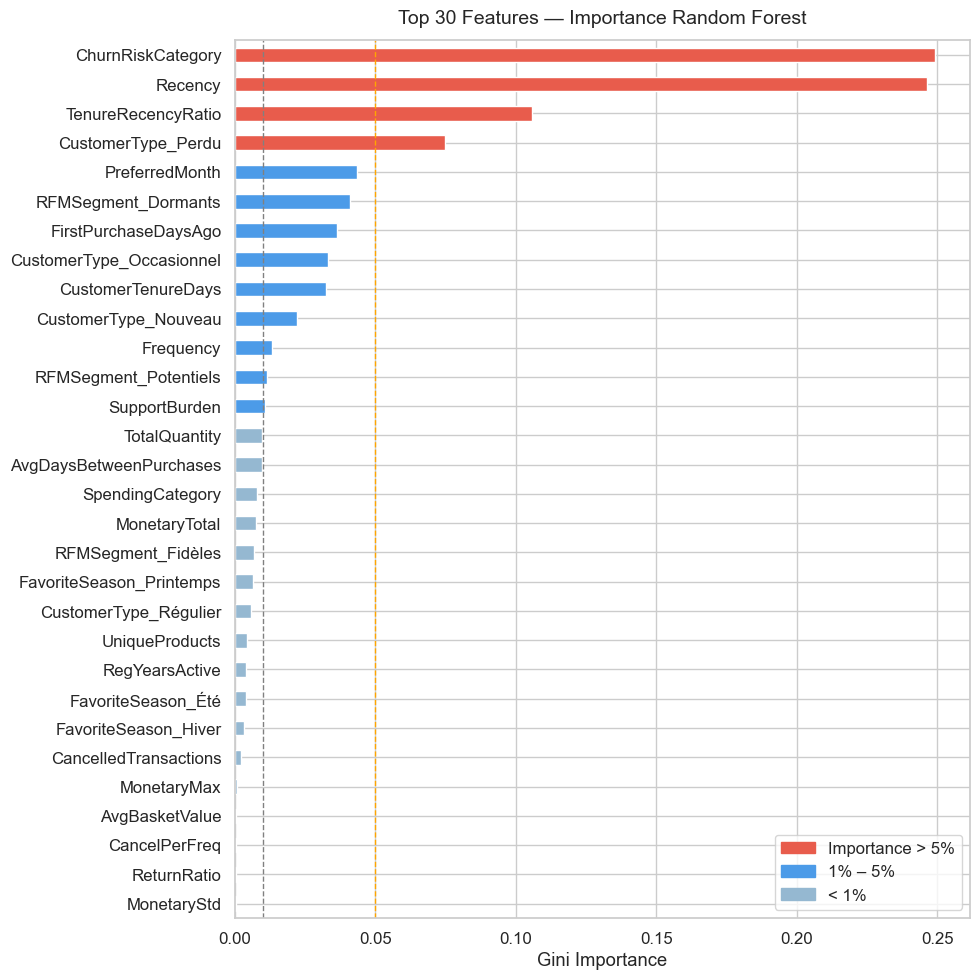

In [33]:
# ── Visualisation des importances (top 30) ────────────────────────────────────
top_imp = importance_series.head(30)

fig, ax = plt.subplots(figsize=(10, 10))
colors_imp = ['#E85C4C' if v > 0.05 else
              '#4C9BE8' if v > 0.01 else '#95B8D1'
              for v in top_imp.values]
top_imp.plot(kind='barh', color=colors_imp, ax=ax, edgecolor='white')
ax.axvline(0.01, color='gray', linestyle='--', lw=1, label='Seuil 0.01')
ax.axvline(0.05, color='orange', linestyle='--', lw=1, label='Seuil 0.05')
ax.set_title('Top 30 Features — Importance Random Forest', fontsize=14, pad=12)
ax.set_xlabel('Gini Importance')
ax.legend()
ax.invert_yaxis()

# Légende des couleurs
patches = [
    mpatches.Patch(color='#E85C4C', label='Importance > 5%'),
    mpatches.Patch(color='#4C9BE8', label='1% – 5%'),
    mpatches.Patch(color='#95B8D1', label='< 1%'),
]
ax.legend(handles=patches, loc='lower right')
plt.tight_layout()
plt.show()

In [34]:
# ── Application de la sélection complète ─────────────────────────────────────
all_cols_to_drop = list(set(
    zero_var_cols +
    high_missing_cols +
    cols_to_drop_corr +
    zero_importance_cols
))
all_cols_to_drop = [c for c in all_cols_to_drop if c in X_full.columns]

X_selected = X_full.drop(columns=all_cols_to_drop)

print('=' * 60)
print('  RÉSUMÉ SÉLECTION DE FEATURES')
print('=' * 60)
print(f'  Features initiales      : {X_full.shape[1]}')
print(f'  Variance nulle          : -{len(zero_var_cols)}')
print(f'  Manquantes > 50%        : -{len(high_missing_cols)}')
print(f'  Forte corrélation       : -{len([c for c in cols_to_drop_corr if c in X_full.columns])}')
print(f'  Importance RF nulle     : -{len([c for c in zero_importance_cols if c in X_full.columns])}')
print(f'  Features conservées     : {X_selected.shape[1]}')
print('=' * 60)

print('\nFeatures conservées :')
for i, c in enumerate(X_selected.columns, 1):
    print(f'  {i:3d}. {c}')

  RÉSUMÉ SÉLECTION DE FEATURES
  Features initiales      : 86
  Variance nulle          : -0
  Manquantes > 50%        : -0
  Forte corrélation       : -15
  Importance RF nulle     : -13
  Features conservées     : 58

Features conservées :
    1. Recency
    2. Frequency
    3. MonetaryTotal
    4. MonetaryAvg
    5. MonetaryStd
    6. MonetaryMax
    7. TotalQuantity
    8. AvgQuantityPerTransaction
    9. CustomerTenureDays
   10. FirstPurchaseDaysAgo
   11. PreferredDayOfWeek
   12. PreferredHour
   13. PreferredMonth
   14. AvgDaysBetweenPurchases
   15. UniqueProducts
   16. ZeroPriceCount
   17. CancelledTransactions
   18. ReturnRatio
   19. Age
   20. SupportTicketsCount
   21. SatisfactionScore
   22. AgeCategory
   23. SpendingCategory
   24. PreferredTimeOfDay
   25. ChurnRiskCategory
   26. BasketSizeCategory
   27. RegMonth
   28. RegDay
   29. RegWeekday
   30. IP_FirstOctet
   31. RFMSegment_Dormants
   32. RFMSegment_Fidèles
   33. RFMSegment_Potentiels
   34. Custome

---
## Étape 4 · Imputation Avancée des Valeurs Manquantes

> **Règle d'or** : le fit d'imputation se fait **uniquement sur X_train**, puis on applique la transformation sur X_test — comme pour le StandardScaler.  
> Imputer sur tout le dataset avant le split = **data leakage**.

In [35]:
# ── Train / Test Split précoce (avant imputation) ────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train : {X_train_raw.shape}  |  Test : {X_test_raw.shape}')
print(f'Churn rate — Train : {y_train.mean():.3f}  |  Test : {y_test.mean():.3f}')
print()
print('Valeurs manquantes dans X_train_raw :')
mv_train = X_train_raw.isnull().sum()
print(mv_train[mv_train > 0].to_frame('NaN count').assign(
    pct=lambda x: (x['NaN count'] / len(X_train_raw) * 100).round(2)
))

Train : (3497, 58)  |  Test : (875, 58)
Churn rate — Train : 0.333  |  Test : 0.333

Valeurs manquantes dans X_train_raw :
                         NaN count     pct
AvgDaysBetweenPurchases         66  1.8900
Age                           1061 30.3400
SupportTicketsCount            105  3.0000
SatisfactionScore              286  8.1800
SupportBurden                  105  3.0000


In [36]:
# ── Colonnes avec NaN ─────────────────────────────────────────────────────────
cols_with_nan = X_train_raw.columns[X_train_raw.isnull().any()].tolist()

# ─────────────────────────────────────────────────────────────────────────────
# STRATÉGIE D'IMPUTATION
# ─────────────────────────────────────────────────────────────────────────────
#
#  AvgDaysBetweenPurchases :  ~1.8% manquant, distribution asymétrique
#                             → Médiane (robuste aux outliers)
#
#  SupportTicketsCount     :  ~3% manquant (après correction aberrants)
#                             → Médiane
#
#  SatisfactionScore       :  ~8% manquant
#                             → Iterative Imputer (régression sur features liées)
#
#  IP_FirstOctet           :  très rare → Médiane
#
#  Age                     :  ~30% manquant, corrélé à plusieurs features
#                             → KNN Imputer (k=5, voisinage multi-features)
# ─────────────────────────────────────────────────────────────────────────────

X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

# ── 4-A : Imputation par médiane (colonnes peu affectées) ────────────────────
median_cols = ['AvgDaysBetweenPurchases', 'SupportTicketsCount', 'IP_FirstOctet', 'SupportBurden']
median_cols = [c for c in median_cols if c in X_train.columns]

medians = X_train[median_cols].median()
X_train[median_cols] = X_train[median_cols].fillna(medians)
X_test[median_cols]  = X_test[median_cols].fillna(medians)  # même médiane de train
print(f'✅  Médiane appliquée sur : {median_cols}')

✅  Médiane appliquée sur : ['AvgDaysBetweenPurchases', 'SupportTicketsCount', 'IP_FirstOctet', 'SupportBurden']


In [37]:
# ── 4-B : Iterative Imputer — SatisfactionScore ───────────────────────────────
#
# IterativeImputer modélise chaque feature avec des NaN comme variable dépendante
# et prédit ses valeurs manquantes via régression sur les autres features.
# Plus précis que la simple médiane pour les features corrélées.

if 'SatisfactionScore' in X_train.columns and X_train['SatisfactionScore'].isna().any():
    iter_imputer = IterativeImputer(
        max_iter=10,
        random_state=42,
        initial_strategy='median'
    )

    # Fit sur train uniquement
    X_train_iter = iter_imputer.fit_transform(X_train[['SatisfactionScore',
                                                        'Recency', 'Frequency',
                                                        'CustomerTenureDays',
                                                        'SpendingCategory']])
    X_test_iter  = iter_imputer.transform(X_test[['SatisfactionScore',
                                                   'Recency', 'Frequency',
                                                   'CustomerTenureDays',
                                                   'SpendingCategory']])

    X_train['SatisfactionScore'] = X_train_iter[:, 0]
    X_test['SatisfactionScore']  = X_test_iter[:, 0]

    # Clip dans la plage valide [1, 5]
    X_train['SatisfactionScore'] = X_train['SatisfactionScore'].clip(1, 5)
    X_test['SatisfactionScore']  = X_test['SatisfactionScore'].clip(1, 5)

    joblib.dump(iter_imputer, r'..\models\iterative_imputer_satisfaction.joblib')
    print('✅  IterativeImputer → SatisfactionScore (clippée [1,5])')

✅  IterativeImputer → SatisfactionScore (clippée [1,5])


In [38]:
# ── 4-C : KNN Imputer — Age (~30% manquant) ────────────────────────────────────
#
# KNNImputer remplace chaque NaN par la moyenne pondérée des k voisins
# les plus proches (basé sur les features non-manquantes du même individu).
# Recommandé quand le % de manquant est élevé ET que la variable est
# corrélée à plusieurs autres features.

knn_context = ['Age', 'Frequency', 'MonetaryTotal', 'CustomerTenureDays',
               'Recency', 'AgeCategory', 'SpendingCategory']
knn_context = [c for c in knn_context if c in X_train.columns]

knn_imputer = KNNImputer(n_neighbors=5)

# Fit sur train, transform train+test
knn_result_train = knn_imputer.fit_transform(X_train[knn_context])
knn_result_test  = knn_imputer.transform(X_test[knn_context])

age_idx = knn_context.index('Age')
X_train['Age'] = knn_result_train[:, age_idx]
X_test['Age']  = knn_result_test[:, age_idx]

# Clip dans la plage valide [18, 81]
X_train['Age'] = X_train['Age'].clip(18, 81)
X_test['Age']  = X_test['Age'].clip(18, 81)

joblib.dump(knn_imputer, r'..\models\knn_imputer_age.joblib')
print(f'✅  KNN Imputer → Age (clippée [18,81])')
print(f'   NaN restants Age (train) : {X_train["Age"].isna().sum()}')

# ── Vérification finale ───────────────────────────────────────────────────────
total_nan_train = X_train.isnull().sum().sum()
total_nan_test  = X_test.isnull().sum().sum()
print(f'\n✅  NaN restants après imputation — Train : {total_nan_train}  |  Test : {total_nan_test}')

✅  KNN Imputer → Age (clippée [18,81])
   NaN restants Age (train) : 0

✅  NaN restants après imputation — Train : 0  |  Test : 0


---
## Étape 5 · Normalisation — StandardScaler

> **StandardScaler** : centre à moyenne 0, réduit à écart-type 1.  
> Essentiel pour SVM, KNN, Régression logistique, Réseaux de neurones, et la **PCA** (qui est sensible à l'échelle).  
> ⚠️ Ne JAMAIS normaliser la variable cible `y`.

In [39]:
# ── Identifier les colonnes à scaler ─────────────────────────────────────────
# On exclut les colonnes binaires (déjà en 0/1)
binary_cols = [
    c for c in X_train.columns
    if X_train[c].nunique() <= 2 and set(X_train[c].dropna().unique()).issubset({0, 1})
]
cols_to_scale = [c for c in X_train.columns if c not in binary_cols]

print(f'Colonnes à scaler   : {len(cols_to_scale)}')
print(f'Colonnes binaires   : {len(binary_cols)}')
print(f'Total features      : {X_train.shape[1]}')

# ── Fit sur train, transform train + test ─────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

joblib.dump(scaler, r'..\models\standard_scaler_v2.joblib')
print('\n✅  StandardScaler fitté sur X_train, appliqué sur X_test')

# ── Vérification post-scaling ─────────────────────────────────────────────────
print('\nStats post-scaling (train, 5 premières features scalées) :')
X_train_scaled[cols_to_scale[:5]].describe().loc[['mean', 'std']].round(4)

Colonnes à scaler   : 37
Colonnes binaires   : 21
Total features      : 58

✅  StandardScaler fitté sur X_train, appliqué sur X_test

Stats post-scaling (train, 5 premières features scalées) :


,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd
mean,0.0000,0.0000,-0.0000,-0.0000,-0.0000
std,1.0001,1.0001,1.0001,1.0001,1.0001


---
## Étape 6 · ACP — Analyse en Composantes Principales

> **Objectif** : Réduire la dimension (N features → 2-10 composantes) tout en conservant un maximum d'information (variance expliquée).  
>
> **Utilité** :
> - Visualisation en 2D/3D du dataset
> - Réduction du bruit
> - Accélération des algorithmes
> - Éviter la malédiction de la dimensionnalité
>
> **Méthode** : Décomposer la variance pour trouver les axes principaux d'inertie (vecteurs propres de la matrice de covariance).

In [40]:
# ── 6-A : Analyse complète de la variance expliquée ──────────────────────────
# On fit la PCA complète d'abord pour choisir le bon nombre de composantes

pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

explained_var  = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Seuils de variance retenue
n_80 = np.argmax(cumulative_var >= 0.80) + 1
n_90 = np.argmax(cumulative_var >= 0.90) + 1
n_95 = np.argmax(cumulative_var >= 0.95) + 1

print('Composantes nécessaires pour retenir :')
print(f'  80% de variance : {n_80:3d} composantes')
print(f'  90% de variance : {n_90:3d} composantes')
print(f'  95% de variance : {n_95:3d} composantes')
print()
print('Variance expliquée par composante (15 premières) :')
for i, (ev, cv) in enumerate(zip(explained_var[:15], cumulative_var[:15]), 1):
    bar = '█' * int(ev * 200)
    print(f'  PC{i:02d}: {ev*100:5.2f}%  (cumulé: {cv*100:6.2f}%)  {bar}')

Composantes nécessaires pour retenir :
  80% de variance :  19 composantes
  90% de variance :  25 composantes
  95% de variance :  32 composantes

Variance expliquée par composante (15 premières) :
  PC01: 13.79%  (cumulé:  13.79%)  ███████████████████████████
  PC02:  7.56%  (cumulé:  21.35%)  ███████████████
  PC03:  6.24%  (cumulé:  27.59%)  ████████████
  PC04:  5.90%  (cumulé:  33.49%)  ███████████
  PC05:  5.14%  (cumulé:  38.63%)  ██████████
  PC06:  4.77%  (cumulé:  43.40%)  █████████
  PC07:  4.24%  (cumulé:  47.64%)  ████████
  PC08:  4.02%  (cumulé:  51.66%)  ████████
  PC09:  3.50%  (cumulé:  55.16%)  ██████
  PC10:  3.32%  (cumulé:  58.48%)  ██████
  PC11:  2.87%  (cumulé:  61.35%)  █████
  PC12:  2.71%  (cumulé:  64.06%)  █████
  PC13:  2.59%  (cumulé:  66.65%)  █████
  PC14:  2.52%  (cumulé:  69.17%)  █████
  PC15:  2.48%  (cumulé:  71.65%)  ████


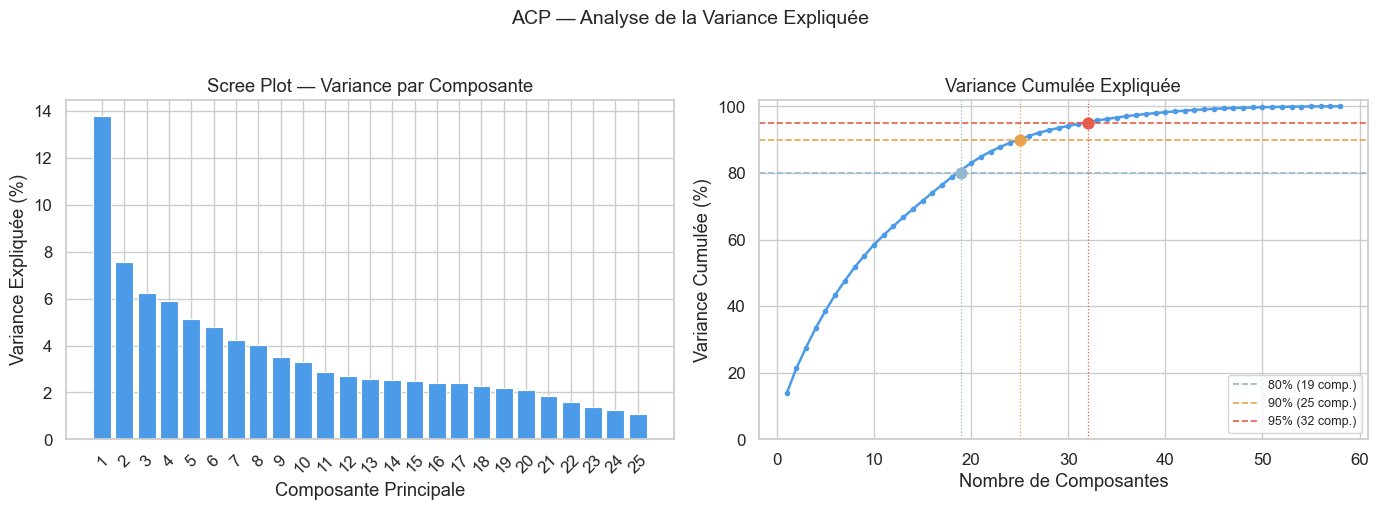

In [41]:
# ── 6-B : Courbe de variance cumulée (Scree Plot) ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot — variance individuelle
axes[0].bar(range(1, 26), explained_var[:25] * 100,
            color='#4C9BE8', edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Composante Principale')
axes[0].set_ylabel('Variance Expliquée (%)')
axes[0].set_title('Scree Plot — Variance par Composante')
axes[0].set_xticks(range(1, 26))
axes[0].tick_params(axis='x', rotation=45)

# Variance cumulée avec seuils
n_display = min(60, len(cumulative_var))
axes[1].plot(range(1, n_display + 1), cumulative_var[:n_display] * 100,
             'o-', color='#4C9BE8', markersize=3, linewidth=1.8)
for threshold, color, n_comp, label in [
    (80, '#95B8D1', n_80, f'{n_80} comp.'),
    (90, '#E8A44C', n_90, f'{n_90} comp.'),
    (95, '#E85C4C', n_95, f'{n_95} comp.'),
]:
    axes[1].axhline(threshold, color=color, linestyle='--', linewidth=1.2,
                    label=f'{threshold}% ({label})')
    axes[1].axvline(n_comp, color=color, linestyle=':', linewidth=0.9)
    axes[1].scatter([n_comp], [threshold], color=color, s=60, zorder=5)

axes[1].set_xlabel('Nombre de Composantes')
axes[1].set_ylabel('Variance Cumulée (%)')
axes[1].set_title('Variance Cumulée Expliquée')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 102)

plt.suptitle('ACP — Analyse de la Variance Expliquée', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [42]:
# ── 6-C : Choix du nombre de composantes ─────────────────────────────────────
#
# On propose 3 versions selon l'usage :
#   ▸ PCA_2  : 2 composantes → visualisation 2D uniquement
#   ▸ PCA_10 : 10 composantes → équilibre réduction/information pour ML
#   ▸ PCA_90 : n_90 composantes → conserve 90% de l'information
#
# Pour la modélisation, PCA_10 (2-10 composantes selon le PDF) est recommandée.

N_COMPONENTS_VIZ = 2
N_COMPONENTS_ML  = 10   # ← valeur recommandée par le PDF (2–10)
N_COMPONENTS_90  = n_90

# ── PCA 2D — Visualisation ────────────────────────────────────────────────────
pca_2d = PCA(n_components=N_COMPONENTS_VIZ, random_state=42)
X_train_pca2  = pca_2d.fit_transform(X_train_scaled)
X_test_pca2   = pca_2d.transform(X_test_scaled)

var_2d = pca_2d.explained_variance_ratio_.sum() * 100
print(f'PCA 2D  : variance retenue = {var_2d:.2f}%')

# ── PCA 10 composantes — Usage ML ────────────────────────────────────────────
pca_10 = PCA(n_components=N_COMPONENTS_ML, random_state=42)
X_train_pca10 = pca_10.fit_transform(X_train_scaled)
X_test_pca10  = pca_10.transform(X_test_scaled)

var_10 = pca_10.explained_variance_ratio_.sum() * 100
print(f'PCA 10  : variance retenue = {var_10:.2f}%')

# ── PCA 90% variance ──────────────────────────────────────────────────────────
pca_90 = PCA(n_components=N_COMPONENTS_90, random_state=42)
X_train_pca90 = pca_90.fit_transform(X_train_scaled)
X_test_pca90  = pca_90.transform(X_test_scaled)

var_90 = pca_90.explained_variance_ratio_.sum() * 100
print(f'PCA {N_COMPONENTS_90:2d}  : variance retenue = {var_90:.2f}%')

joblib.dump(pca_2d,  r'..\models\pca_2d.joblib')
joblib.dump(pca_10,  r'..\models\pca_10.joblib')
joblib.dump(pca_90,  r'..\models\pca_90.joblib')
print('\n✅  Modèles PCA sauvegardés')

PCA 2D  : variance retenue = 21.35%
PCA 10  : variance retenue = 58.48%
PCA 25  : variance retenue = 90.14%

✅  Modèles PCA sauvegardés


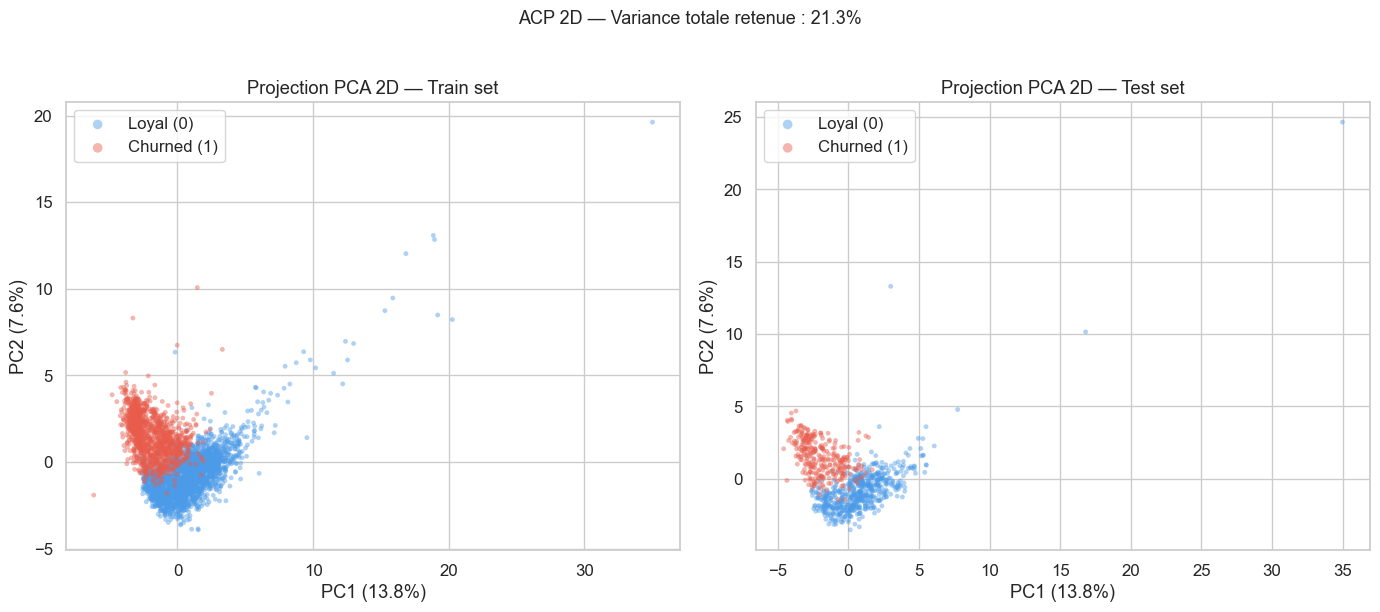

In [43]:
# ── 6-D : Visualisation 2D des données projetées ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_churn = {0: '#4C9BE8', 1: '#E85C4C'}
labels_churn = {0: 'Loyal (0)', 1: 'Churned (1)'}

for ax, (X_proj, title) in zip(axes, [
    (X_train_pca2, 'Train set'),
    (X_test_pca2, 'Test set')
]):
    y_plot = y_train if 'Train' in title else y_test
    for label in [0, 1]:
        mask_l = (np.array(y_plot) == label)
        ax.scatter(
            X_proj[mask_l, 0], X_proj[mask_l, 1],
            c=colors_churn[label], label=labels_churn[label],
            alpha=0.45, s=12, edgecolors='none'
        )
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(f'Projection PCA 2D — {title}')
    ax.legend(markerscale=2)

plt.suptitle(f'ACP 2D — Variance totale retenue : {var_2d:.1f}%', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

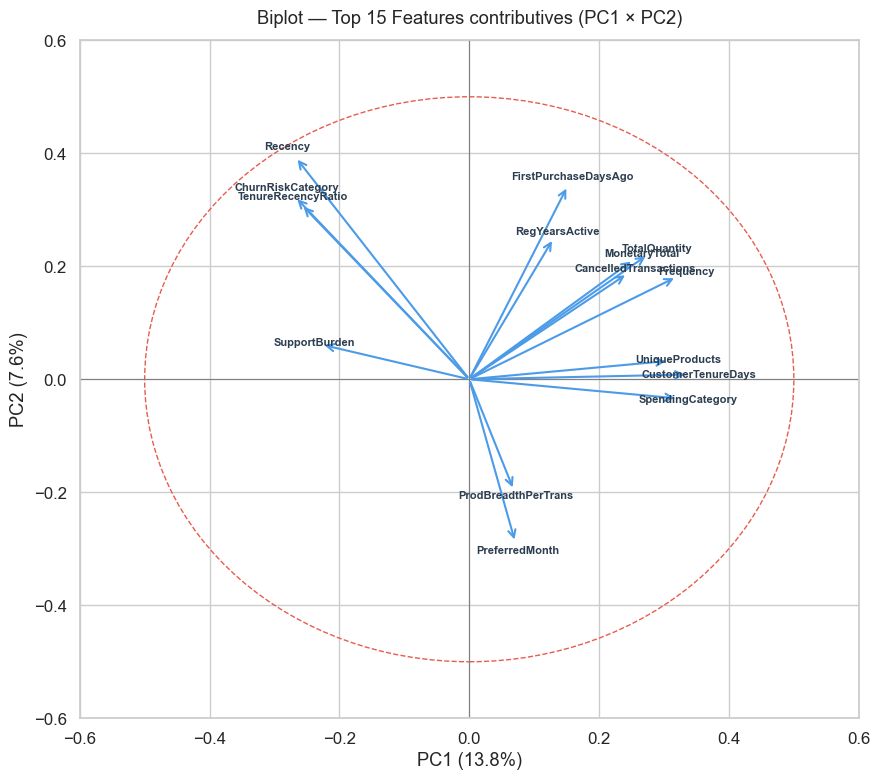

In [44]:
# ── 6-E : Biplot — Contribution des features originales aux 2 premières PC ───
# On visualise quelles features tirent le plus les composantes

loadings = pd.DataFrame(
    pca_10.components_[:2].T,
    index=X_train_scaled.columns,
    columns=['PC1', 'PC2']
)

# Top 15 features par norme (impact combiné sur PC1 et PC2)
loadings['norm'] = np.sqrt(loadings['PC1']**2 + loadings['PC2']**2)
top_loadings = loadings.nlargest(15, 'norm')

fig, ax = plt.subplots(figsize=(9, 8))
ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)

for feat, row in top_loadings.iterrows():
    ax.annotate('', xy=(row['PC1'], row['PC2']), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#4C9BE8', lw=1.5))
    ax.text(row['PC1'] * 1.05, row['PC2'] * 1.05, feat,
            fontsize=8, ha='center', va='center',
            color='#2C3E50', fontweight='bold')

ax.set_xlim(-0.6, 0.6)
ax.set_ylim(-0.6, 0.6)
ax.set_xlabel(f'PC1 ({pca_10.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_10.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Biplot — Top 15 Features contributives (PC1 × PC2)', pad=12)
circle = plt.Circle((0, 0), 0.5, fill=False, color='#E85C4C', linestyle='--', linewidth=1)
ax.add_patch(circle)
plt.tight_layout()
plt.show()

In [45]:
# ── 6-F : Nommer les composantes principales (interprétation) ─────────────────
print('Interprétation des 10 premières composantes principales :\n')
component_names = []
for i in range(min(10, pca_10.n_components_)):
    pc_loadings = pd.Series(
        pca_10.components_[i],
        index=X_train_scaled.columns
    ).abs().sort_values(ascending=False)
    top3 = pc_loadings.head(3)
    name = f'PC{i+1} ({pca_10.explained_variance_ratio_[i]*100:.1f}%)'
    print(f'  {name:22s} → dominé par : {", ".join(top3.index.tolist())}')
    component_names.append(name)

Interprétation des 10 premières composantes principales :

  PC1 (13.8%)            → dominé par : CustomerTenureDays, SpendingCategory, Frequency
  PC2 (7.6%)             → dominé par : Recency, FirstPurchaseDaysAgo, ChurnRiskCategory
  PC3 (6.2%)             → dominé par : AvgBasketValue, MonetaryAvg, AvgQuantityPerTransaction
  PC4 (5.9%)             → dominé par : PreferredHour, PreferredTimeOfDay, AvgDaysBetweenPurchases
  PC5 (5.1%)             → dominé par : MonetaryStd, MonetaryMax, ReturnRatio
  PC6 (4.8%)             → dominé par : PreferredHour, PreferredTimeOfDay, MonetaryMax
  PC7 (4.2%)             → dominé par : PreferredTimeOfDay, PreferredHour, ProdBreadthPerTrans
  PC8 (4.0%)             → dominé par : AgeCategory, Age, MonetaryAvg
  PC9 (3.5%)             → dominé par : RegMonth, SupportTicketsCount, RegYearsActive
  PC10 (3.3%)            → dominé par : CancelPerFreq, ProdBreadthPerTrans, RegMonth


---
## Étape 7 · Préparation des Datasets Finaux + SMOTE

In [46]:
# ── Nommer les colonnes PCA ───────────────────────────────────────────────────
pca10_cols = [f'PC{i+1}' for i in range(N_COMPONENTS_ML)]
pca90_cols = [f'PC{i+1}' for i in range(N_COMPONENTS_90)]

X_train_pca10_df = pd.DataFrame(X_train_pca10, columns=pca10_cols)
X_test_pca10_df  = pd.DataFrame(X_test_pca10,  columns=pca10_cols)
X_train_pca90_df = pd.DataFrame(X_train_pca90, columns=pca90_cols)
X_test_pca90_df  = pd.DataFrame(X_test_pca90,  columns=pca90_cols)

# ── SMOTE uniquement sur X_train (jamais sur test !) ──────────────────────────
print('Distribution Churn avant SMOTE (train) :')
print(y_train.value_counts())

smote = SMOTE(random_state=42, k_neighbors=5)

# Sur features scalées (pour les modèles non-PCA)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Sur features PCA-10
X_train_pca10_smote, y_train_pca10_smote = smote.fit_resample(X_train_pca10_df, y_train)

print('\nDistribution Churn après SMOTE (train) :')
print(pd.Series(y_train_smote).value_counts())
print(f'\n✅  Datasets SMOTE prêts')

Distribution Churn avant SMOTE (train) :
Churn
0    2334
1    1163
Name: count, dtype: int64

Distribution Churn après SMOTE (train) :
Churn
0    2334
1    2334
Name: count, dtype: int64

✅  Datasets SMOTE prêts


---
## Étape 8 · Export Complet

In [47]:

# ── A. Features scalées (sans PCA) ────────────────────────────────────────────
X_train_scaled.to_csv(r'..\data\train_test\X_train_scaled.csv', index=False)
X_test_scaled.to_csv(r'..\data\train_test\X_test_scaled.csv',   index=False)
y_train.to_csv(r'..\data\train_test\y_train.csv', index=False)
y_test.to_csv(r'..\data\train_test\y_test.csv',   index=False)

# ── B. Features scalées + SMOTE ────────────────────────────────────────────────
pd.DataFrame(X_train_smote, columns=X_train_scaled.columns).to_csv(
    r'..\data\train_test\X_train_scaled_smote.csv', index=False)
pd.Series(y_train_smote, name='Churn').to_csv(
    r'..\data\train_test\y_train_smote.csv', index=False)

# ── C. PCA 10 composantes ──────────────────────────────────────────────────────
X_train_pca10_df.to_csv(r'..\data\train_test\X_train_pca10.csv', index=False)
X_test_pca10_df.to_csv(r'..\data\train_test\X_test_pca10.csv',   index=False)

# ── D. PCA 10 + SMOTE ─────────────────────────────────────────────────────────
pd.DataFrame(X_train_pca10_smote, columns=pca10_cols).to_csv(
    r'..\data\train_test\X_train_pca10_smote.csv', index=False)
pd.Series(y_train_pca10_smote, name='Churn').to_csv(
    r'..\data\train_test\y_train_pca10_smote.csv', index=False)

# ── E. PCA 90% variance ────────────────────────────────────────────────────────
X_train_pca90_df.to_csv(r'..\data\train_test\X_train_pca90.csv', index=False)
X_test_pca90_df.to_csv(r'..\data\train_test\X_test_pca90.csv',   index=False)

# ── F. Dataset processed complet (avant split) ────────────────────────────────
df_final = pd.concat([
    X_selected.reset_index(drop=True),
    y.reset_index(drop=True)
], axis=1)
df_final.to_csv(r'..\data\processed\retail_customers_selected_features.csv', index=False)

print('Fichiers sauvegardés :')
saved_files = [
    r'..\data\train_test\X_train_scaled.csv',
    r'..\data\train_test\X_test_scaled.csv',
    r'..\data\train_test\y_train.csv',
    r'..\data\train_test\y_test.csv',
    r'..\data\train_test\X_train_scaled_smote.csv',
    r'..\data\train_test\y_train_smote.csv',
    r'..\data\train_test\X_train_pca10.csv',
    r'..\data\train_test\X_test_pca10.csv',
    r'..\data\train_test\X_train_pca10_smote.csv',
    r'..\data\train_test\y_train_pca10_smote.csv',
    r'..\data\train_test\X_train_pca90.csv',
    r'..\data\train_test\X_test_pca90.csv',
    r'..\data\processed\retail_customers_selected_features.csv',
]
for f in saved_files:
    print(f'  ✅  {f}')

models_saved = [
    r'..\models\standard_scaler_v2.joblib',
    r'..\models\knn_imputer_age.joblib',
    r'..\models\iterative_imputer_satisfaction.joblib',
    r'..\models\pca_2d.joblib',
    r'..\models\pca_10.joblib',
    r'..\models\pca_90.joblib',
]
print('\nModèles sauvegardés :')
for m in models_saved:
    print(f'  ✅  {m}')

Fichiers sauvegardés :
  ✅  ..\data\train_test\X_train_scaled.csv
  ✅  ..\data\train_test\X_test_scaled.csv
  ✅  ..\data\train_test\y_train.csv
  ✅  ..\data\train_test\y_test.csv
  ✅  ..\data\train_test\X_train_scaled_smote.csv
  ✅  ..\data\train_test\y_train_smote.csv
  ✅  ..\data\train_test\X_train_pca10.csv
  ✅  ..\data\train_test\X_test_pca10.csv
  ✅  ..\data\train_test\X_train_pca10_smote.csv
  ✅  ..\data\train_test\y_train_pca10_smote.csv
  ✅  ..\data\train_test\X_train_pca90.csv
  ✅  ..\data\train_test\X_test_pca90.csv
  ✅  ..\data\processed\retail_customers_selected_features.csv

Modèles sauvegardés :
  ✅  ..\models\standard_scaler_v2.joblib
  ✅  ..\models\knn_imputer_age.joblib
  ✅  ..\models\iterative_imputer_satisfaction.joblib
  ✅  ..\models\pca_2d.joblib
  ✅  ..\models\pca_10.joblib
  ✅  ..\models\pca_90.joblib


---
## Récapitulatif Final du Pipeline

In [48]:
print('=' * 70)
print('         PIPELINE COMPLET — RÉCAPITULATIF FINAL')
print('=' * 70)
print(f'  Dataset brut            : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')
print()
print('  ── TRANSFORMATIONS ──────────────────────────────────────────')
steps = [
    ('Suppression constante',      'NewsletterSubscribed'),
    ('Parsing dates',              'RegistrationDate → 4 features'),
    ('Engineering IP',             'LastLoginIP → IP_IsPrivate, IP_FirstOctet'),
    ('Correction aberrants',       'SupportTickets, SatisfactionScore'),
    ('Encodage ordinal',           '6 features catégorielles'),
    ('One-Hot Encoding',           '8 features → colonnes binaires'),
    ('Target Encoding',            'Country (37+ niveaux)'),
    ('Feature Engineering',        '10 nouvelles features dérivées'),
]
for name, detail in steps:
    print(f'  ✅  {name:28s} : {detail}')
print()
print(f'  ── SÉLECTION DE FEATURES ({X_full.shape[1]} → {X_selected.shape[1]}) ─────────────────')
print(f'  ✅  Variance nulle         : {len(zero_var_cols)} features supprimées')
print(f'  ✅  Manquantes > 50%       : {len(high_missing_cols)} features supprimées')
print(f'  ✅  Forte corrélation      : {len([c for c in cols_to_drop_corr if c in X_full.columns])} features supprimées')
print(f'  ✅  Importance RF nulle    : {len([c for c in zero_importance_cols if c in X_full.columns])} features supprimées')
print()
print(f'  ── IMPUTATION & NORMALISATION ──────────────────────────────')
print(f'  ✅  Médiane                : AvgDaysBetweenPurchases, SupportTickets...')
print(f'  ✅  Iterative Imputer      : SatisfactionScore')
print(f'  ✅  KNN Imputer (k=5)      : Age (~30% manquant)')
print(f'  ✅  StandardScaler         : fit train → transform train+test')
print()
print(f'  ── ACP ──────────────────────────────────────────────────────')
print(f'  ✅  PCA 2D                 : {var_2d:.1f}% variance (visualisation)')
print(f'  ✅  PCA 10 composantes     : {var_10:.1f}% variance (modélisation ML)')
print(f'  ✅  PCA {N_COMPONENTS_90:2d} composantes    : {var_90:.1f}% variance (90% retenu)')
print()
print(f'  ── DONNÉES FINALES ──────────────────────────────────────────')
print(f'  Features sélectionnées  : {X_selected.shape[1]}')
print(f'  Train (brut)            : {X_train_scaled.shape[0]:,} × {X_train_scaled.shape[1]}')
print(f'  Train (SMOTE)           : {len(y_train_smote):,} × {X_train_scaled.shape[1]}')
print(f'  Test                    : {X_test_scaled.shape[0]:,} × {X_test_scaled.shape[1]}')
print(f'  Train PCA-10            : {X_train_pca10.shape[0]:,} × {X_train_pca10.shape[1]}')
print(f'  Train PCA-10 (SMOTE)    : {X_train_pca10_smote.shape[0]:,} × {X_train_pca10_smote.shape[1]}')
print('=' * 70)
print('  ✅  PRÊT POUR : Clustering · Classification · Régression')
print('=' * 70)

         PIPELINE COMPLET — RÉCAPITULATIF FINAL
  Dataset brut            : 4,372 lignes × 52 colonnes

  ── TRANSFORMATIONS ──────────────────────────────────────────
  ✅  Suppression constante        : NewsletterSubscribed
  ✅  Parsing dates                : RegistrationDate → 4 features
  ✅  Engineering IP               : LastLoginIP → IP_IsPrivate, IP_FirstOctet
  ✅  Correction aberrants         : SupportTickets, SatisfactionScore
  ✅  Encodage ordinal             : 6 features catégorielles
  ✅  One-Hot Encoding             : 8 features → colonnes binaires
  ✅  Target Encoding              : Country (37+ niveaux)
  ✅  Feature Engineering          : 10 nouvelles features dérivées

  ── SÉLECTION DE FEATURES (86 → 58) ─────────────────
  ✅  Variance nulle         : 0 features supprimées
  ✅  Manquantes > 50%       : 0 features supprimées
  ✅  Forte corrélation      : 15 features supprimées
  ✅  Importance RF nulle    : 13 features supprimées

  ── IMPUTATION & NORMALISATION ─────────